In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings, os, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets, load_psd_results, aggregate_population,
    run_population_tests, run_fraction_sig_tests, run_r2_tests,
    plot_population_results, plot_r2_distributions, plot_beta_distributions,
    build_population_scatter, save_population_results,
    compare_hpf_versions, show_beta_tables, plot_target_correlations,
    plot_r2_summary,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

In [2]:
# ── Run-control flags ───────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


# Population ridge regression — spe-1

Pool single-cell ridge regression results (n=37 cells) and test whether spike waveform features systematically predict pre/post-spike LFP state.

| § | What |
|---|------|
| 1 | Load per-cell result pickles |
| 2 | Aggregate R², significance flags, and beta weights |
| 3 | Population tests: R² > 0 (primary), fraction significant (binomial), beta consistency |
| 4 | Visualisations: R² and beta heatmaps, per-cell R² distributions, beta distributions |
| 5 | Actual vs predicted scatter (pooled, z-scored within cell) |
| 6 | Save population pickle |
| 7 | HPF vs no-HPF comparison for amp/std targets |

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
ALPHA            = 0.05   # significance threshold (each test assessed independently)
MIN_CELLS        = 5

## Configuration

`PRE_WIN` / `POST_WIN`: time windows (s) around the spike for LFP feature extraction.  
`ALPHA`: significance threshold (default 0.05). Each target is tested independently — no correction across targets.  
`MIN_CELLS`: minimum cells required to run a population test.

**LFP targets (14 total)**  
Pre and Post absolute windows × 5 LFP features. LFP Amp and LFP Std appear as both raw and HPF (0.1 Hz zero-phase Butterworth) variants. Baseline-corrected variants are excluded — HPF handles detrending.

**Statistical approach**  
Each LFP target = a distinct scientific question, tested independently at α = 0.05. No correction across targets.

In [4]:
# ── 1. Load — merge HPF amp/std as named targets, drop BL-corrected and Δ ──────
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

Merged: 37 cells  |  18 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)


In [5]:
# ── 1b. Load single-PSD results ──────────────────────────────────────────────
(all_results_psd, cell_ids_psd,
 target_names_psd, target_labels_psd,
 predictor_sets_psd) = load_psd_results(RIDGE_PICKLE_DIR, FEAT_LABELS)

PSD: 42 cells  |  14 targets (Pre+Post abs, single-PSD method, theta=4–15 Hz, slow_gamma=30–60 Hz, high_gamma=60–80 Hz)


## 1. Load per-cell results

14 targets: Pre and Post windows for each of the 5 LFP features. LFP Amp and LFP Std appear twice — once using raw LFP windows and once with 0.1 Hz HPF detrending. Baseline-corrected and Δ variants are excluded (HPF handles detrending for amp/std; gamma/exponent/theta are unaffected by slow drift).

In [6]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

In [7]:
# ── 2b-psd. Aggregate single-PSD R², significance, and betas ─────────────────
r2_pop_psd, sig_pop_psd, beta_pop_psd = aggregate_population(
    all_results_psd, cell_ids_psd, target_names_psd, predictor_sets_psd,
)

## 2. Aggregate across cells

`r2_pop`   — CV R² per cell per (target × predictor set)  
`sig_pop`  — per-cell significance flags (raw permutation p < 0.05, each target independent)  
`beta_pop` — waveform beta weights (Waveform only model) per cell

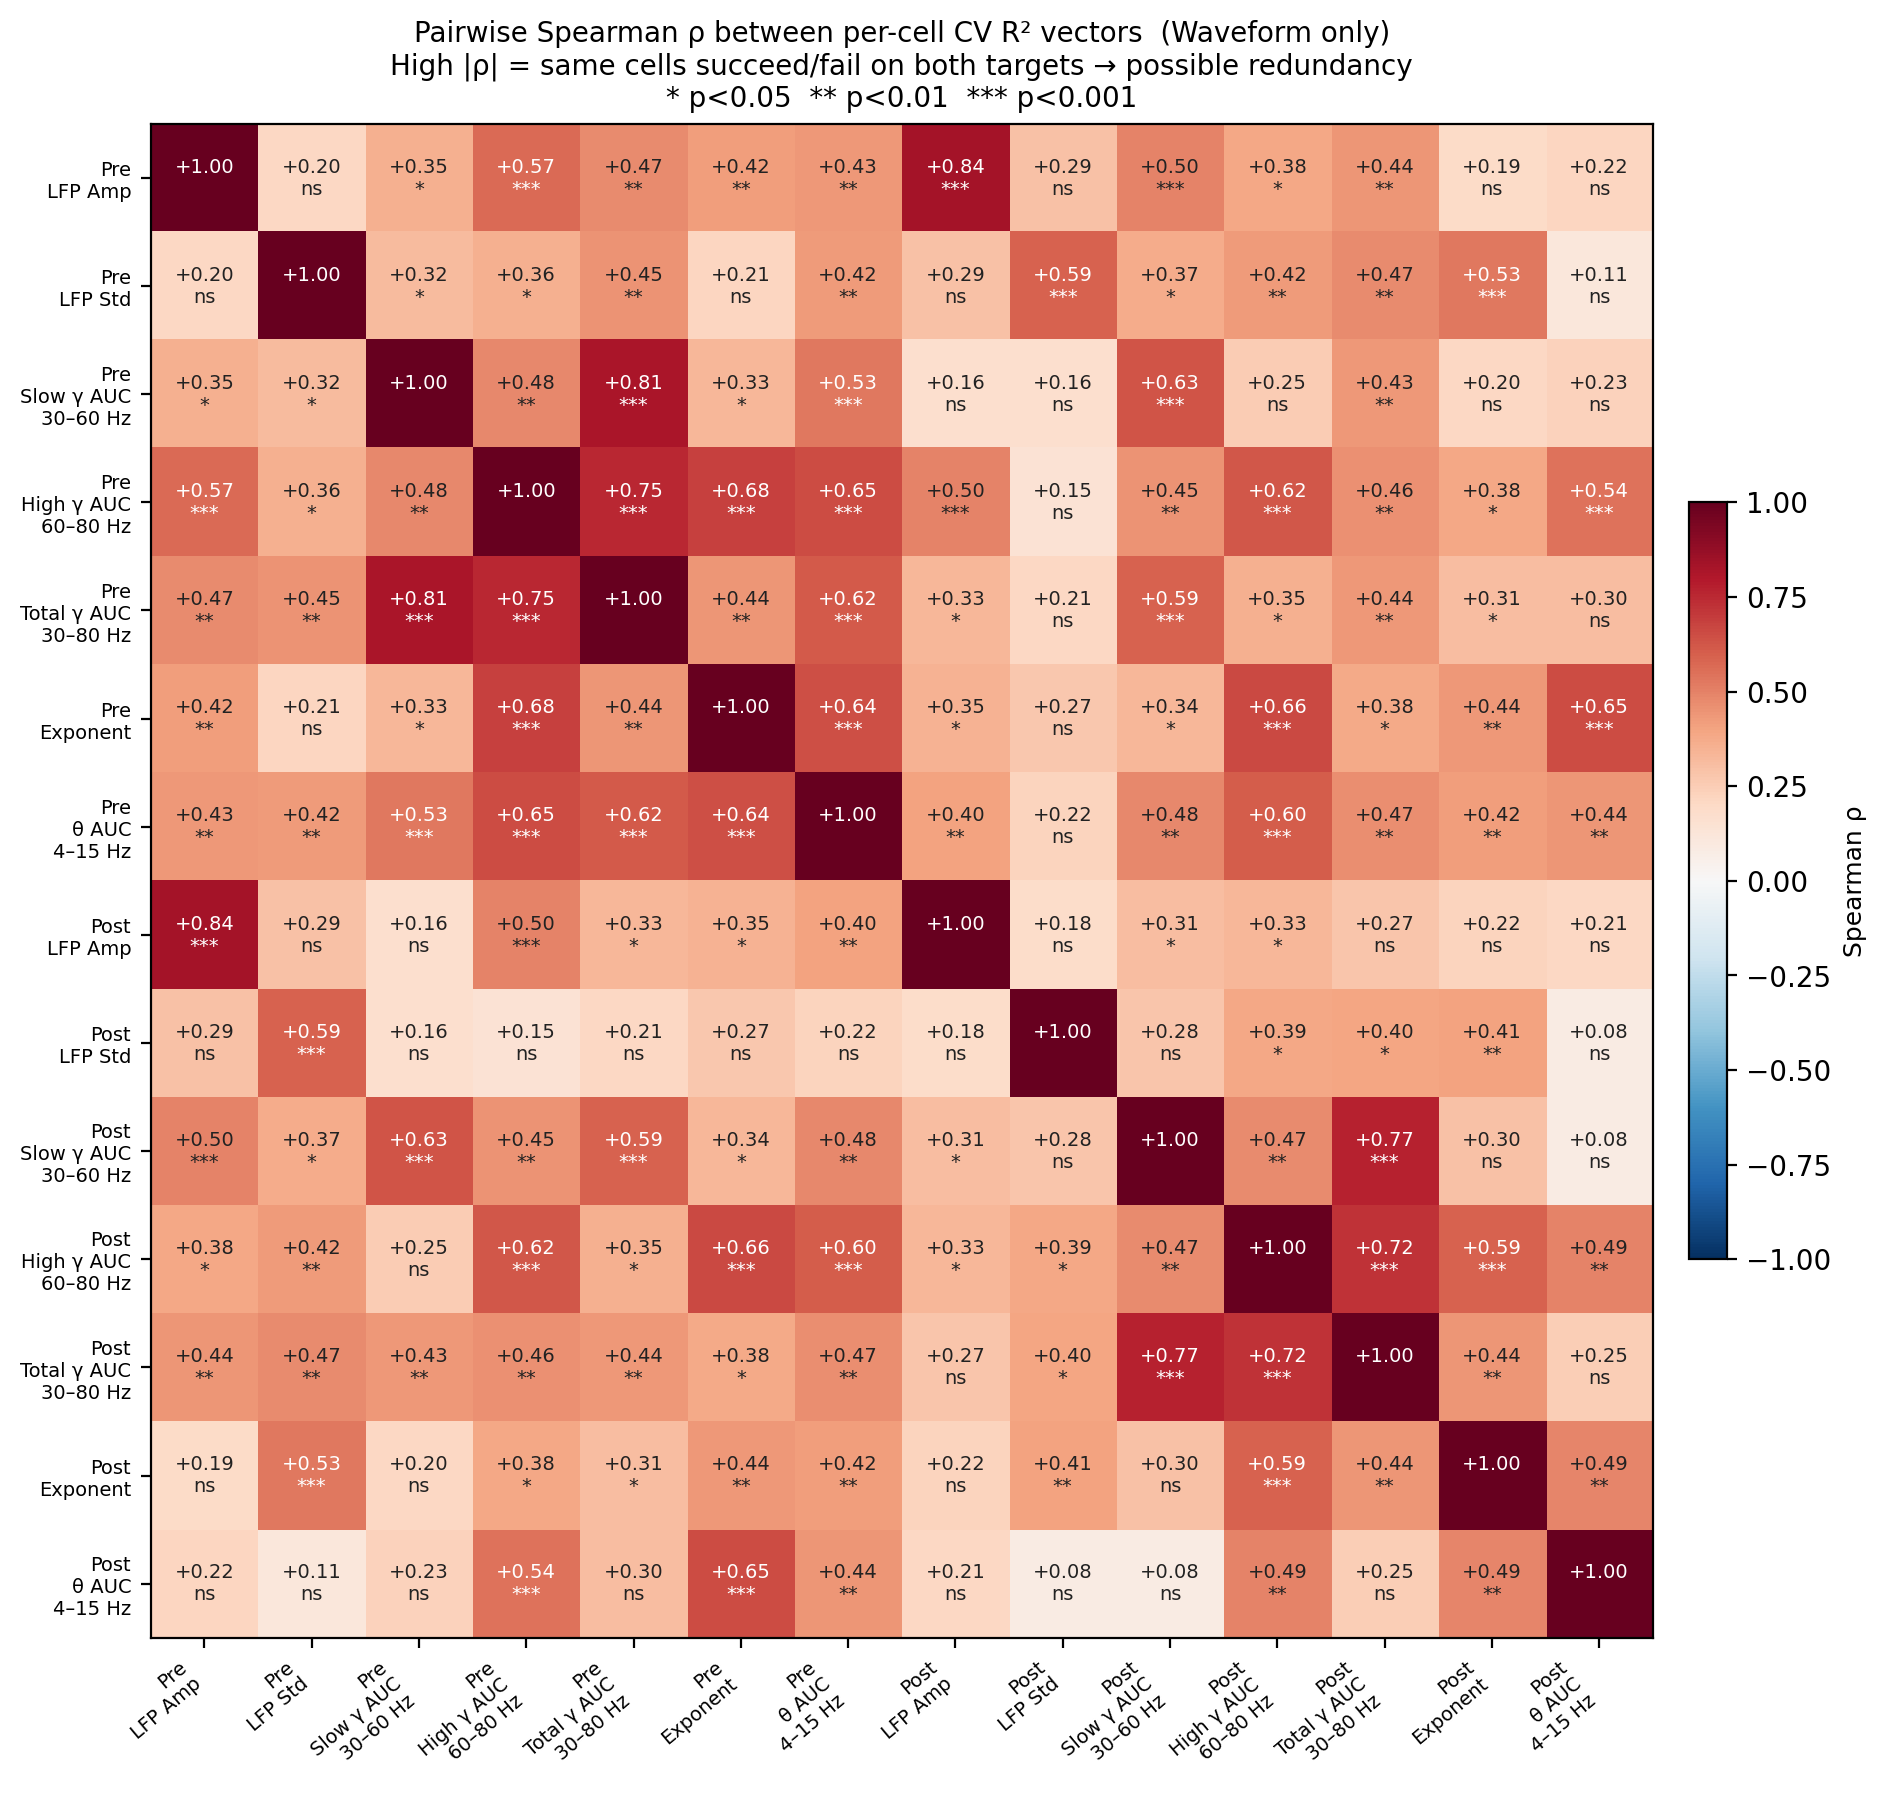


Highly correlated pairs (|ρ| ≥ 0.7):
  Pre LFP Amp                          ×  Post LFP Amp                         ρ = +0.836  p = < 0.0001
  Pre Slow γ AUC
30–60 Hz              ×  Pre Total γ AUC
30–80 Hz             ρ = +0.814  p = < 0.0001
  Post Slow γ AUC
30–60 Hz             ×  Post Total γ AUC
30–80 Hz            ρ = +0.773  p = < 0.0001
  Pre High γ AUC
60–80 Hz              ×  Pre Total γ AUC
30–80 Hz             ρ = +0.754  p = < 0.0001
  Post High γ AUC
60–80 Hz             ×  Post Total γ AUC
30–80 Hz            ρ = +0.721  p = < 0.0001


In [8]:
# ── 2b. Target correlation check ──────────────────────────────────────────────
# Are any LFP targets redundant? High Spearman ρ between per-cell R² vectors
# means the same cells succeed/fail on both targets → possible redundancy.
plot_target_correlations(r2_pop_psd, target_names_psd, target_labels_psd)

## 2b. Target correlation check

Pairwise Spearman ρ between per-cell R² vectors across all 14 targets. High |ρ| means the same cells succeed/fail on both — suggesting redundancy. Informs whether any targets can be dropped without losing information.

In [9]:
# ── 3. Population tests ───────────────────────────────────────────────────────
df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)

sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
print(f'\nR²-significant targets (Waveform only): {sig_r2_targets}')

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

Fraction-sig binomial tests: 54 pairs  |  p<0.05: 36 (each target tested independently)
       target_label      predictor_set  n_sig  n_cells  frac_sig
        Pre LFP Amp      Waveform only     32       37  0.864865
        Pre LFP Amp       Log ISI only     19       37  0.513514
        Pre LFP Amp Waveform + Log ISI     33       37  0.891892
  Pre LFP Amp (HPF)      Waveform only     25       37  0.675676
  Pre LFP Amp (HPF)       Log ISI only     16       37  0.432432
  Pre LFP Amp (HPF) Waveform + Log ISI     27       37  0.729730
        Pre LFP Std      Waveform only     30       37  0.810811
        Pre LFP Std       Log ISI only     15       37  0.405405
        Pre LFP Std Waveform + Log ISI     32       37  0.864865
  Pre LFP Std (HPF)      Waveform only     19       37  0.513514
  Pre LFP Std (HPF)       Log ISI only     13       37  0.351351
  Pre LFP Std (HPF) Waveform + Log ISI     24       37  0.648649
       Pre Exponent      Waveform only     17       37  0.459459
  

In [10]:
# ── 3-psd. Population tests — single-PSD method ─────────────────────────────
df_frac_psd = run_fraction_sig_tests(
    sig_pop_psd, target_names_psd, target_labels_psd, predictor_sets_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2_psd = run_r2_tests(
    r2_pop_psd, target_names_psd, target_labels_psd, predictor_sets_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets_psd = (
    df_r2_psd[df_r2_psd['sig_r2'] & (df_r2_psd['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
df_tests_psd = run_population_tests(
    beta_pop_psd, target_names_psd, target_labels_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets_psd,
)

Fraction-sig binomial tests: 42 pairs  |  p<0.05: 40 (each target tested independently)
              target_label      predictor_set  n_sig  n_cells  frac_sig
               Pre LFP Amp      Waveform only     28       42  0.666667
               Pre LFP Amp       Log ISI only     17       42  0.404762
               Pre LFP Amp Waveform + Log ISI     30       42  0.714286
               Pre LFP Std      Waveform only     20       42  0.476190
               Pre LFP Std       Log ISI only     13       42  0.309524
               Pre LFP Std Waveform + Log ISI     25       42  0.595238
  Pre Slow γ AUC\n30–60 Hz      Waveform only     16       42  0.380952
  Pre Slow γ AUC\n30–60 Hz       Log ISI only     16       42  0.380952
  Pre Slow γ AUC\n30–60 Hz Waveform + Log ISI     20       42  0.476190
  Pre High γ AUC\n60–80 Hz      Waveform only     10       42  0.238095
  Pre High γ AUC\n60–80 Hz       Log ISI only     11       42  0.261905
  Pre High γ AUC\n60–80 Hz Waveform + Log ISI   

In [11]:
# ── 3c. Beta tables — R²-significant targets ──────────────────────────────────
show_beta_tables(df_tests, sig_r2_targets, target_names, target_labels, r2_pop=r2_pop)

,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Sharpness,37,-0.0550,0.0294,0.0286,*
1,Infl. Amp,37,+0.0323,0.0157,0.0349,*
2,Ramp Amp,37,-0.0176,0.0066,0.0407,*
3,Decay λ,37,+0.0275,0.0131,0.1139,ns
4,Infl. Time,37,+0.0081,0.0077,0.1287,ns
5,Peak Width,37,-0.0242,0.0200,0.1969,ns
6,Peak Amp,37,+0.0544,0.0401,0.3777,ns
7,Decay Const,37,-0.0074,0.0114,0.4026,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Infl. Amp,37,+0.0221,0.0097,0.0189,*
1,Ramp Amp,37,-0.0082,0.0045,0.2023,ns
2,Sharpness,37,-0.0411,0.0323,0.2364,ns
3,Infl. Time,37,+0.0054,0.0043,0.2424,ns
4,Decay λ,37,-0.0098,0.0100,0.4026,ns
5,Peak Amp,37,+0.0211,0.0311,0.6015,ns
6,Decay Const,37,+0.0081,0.0089,0.9169,ns
7,Peak Width,37,-0.0027,0.0137,0.9643,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Decay Const,37,+0.0084,0.0103,0.1037,ns
1,Ramp Amp,37,+0.0039,0.0033,0.3538,ns
2,Infl. Time,37,-0.0018,0.0056,0.3617,ns
3,Sharpness,37,+0.0066,0.0128,0.5307,ns
4,Peak Width,37,+0.0045,0.0136,0.6438,ns
5,Infl. Amp,37,-0.0071,0.0078,0.6762,ns
6,Peak Amp,37,-0.0101,0.0221,0.9287,ns
7,Decay λ,37,-0.0000,0.0090,0.9643,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Ramp Amp,37,-0.0173,0.0063,0.0224,*
1,Infl. Amp,37,+0.0332,0.0157,0.0264,*
2,Sharpness,37,-0.0544,0.0295,0.0298,*
3,Decay λ,37,+0.0274,0.0128,0.1005,ns
4,Infl. Time,37,+0.0081,0.0077,0.1139,ns
5,Peak Width,37,-0.0213,0.0195,0.2549,ns
6,Peak Amp,37,+0.0515,0.0398,0.3942,ns
7,Decay Const,37,-0.0056,0.0112,0.5505,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Sharpness,37,-0.0715,0.0274,0.0943,ns
1,Infl. Time,37,+0.0058,0.0044,0.1175,ns
2,Infl. Amp,37,+0.0222,0.0105,0.1175,ns
3,Ramp Amp,37,-0.0107,0.0051,0.1624,ns
4,Peak Width,37,-0.0121,0.0124,0.5707,ns
5,Decay λ,37,+0.0008,0.0081,0.7204,ns
6,Decay Const,37,-0.0012,0.0099,0.8933,ns
7,Peak Amp,37,+0.0354,0.0319,0.9762,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Decay Const,37,+0.0101,0.0100,0.0423,*
1,Peak Width,37,+0.0098,0.0139,0.2189,ns
2,Infl. Time,37,-0.0011,0.0057,0.3617,ns
3,Sharpness,37,+0.0039,0.0110,0.6438,ns
4,Ramp Amp,37,+0.0032,0.0036,0.6545,ns
5,Decay λ,37,-0.0008,0.0086,0.6653,ns
6,Peak Amp,37,-0.0122,0.0210,0.8933,ns
7,Infl. Amp,37,-0.0020,0.0069,0.9881,ns


## 3. Population tests

**R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. Primary test — is the median effect size above zero? Each target assessed at α = 0.05 independently.

**Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of cells with p < 0.05 (per target, per cell) greater than the chance level of 5%? Each target tested independently.

**Beta consistency** (`run_population_tests`): one-sample t-test + Wilcoxon on beta weights across cells — do they have a consistent non-zero direction? Restricted to R²-significant targets; within each target, assessed across 8 waveform features.

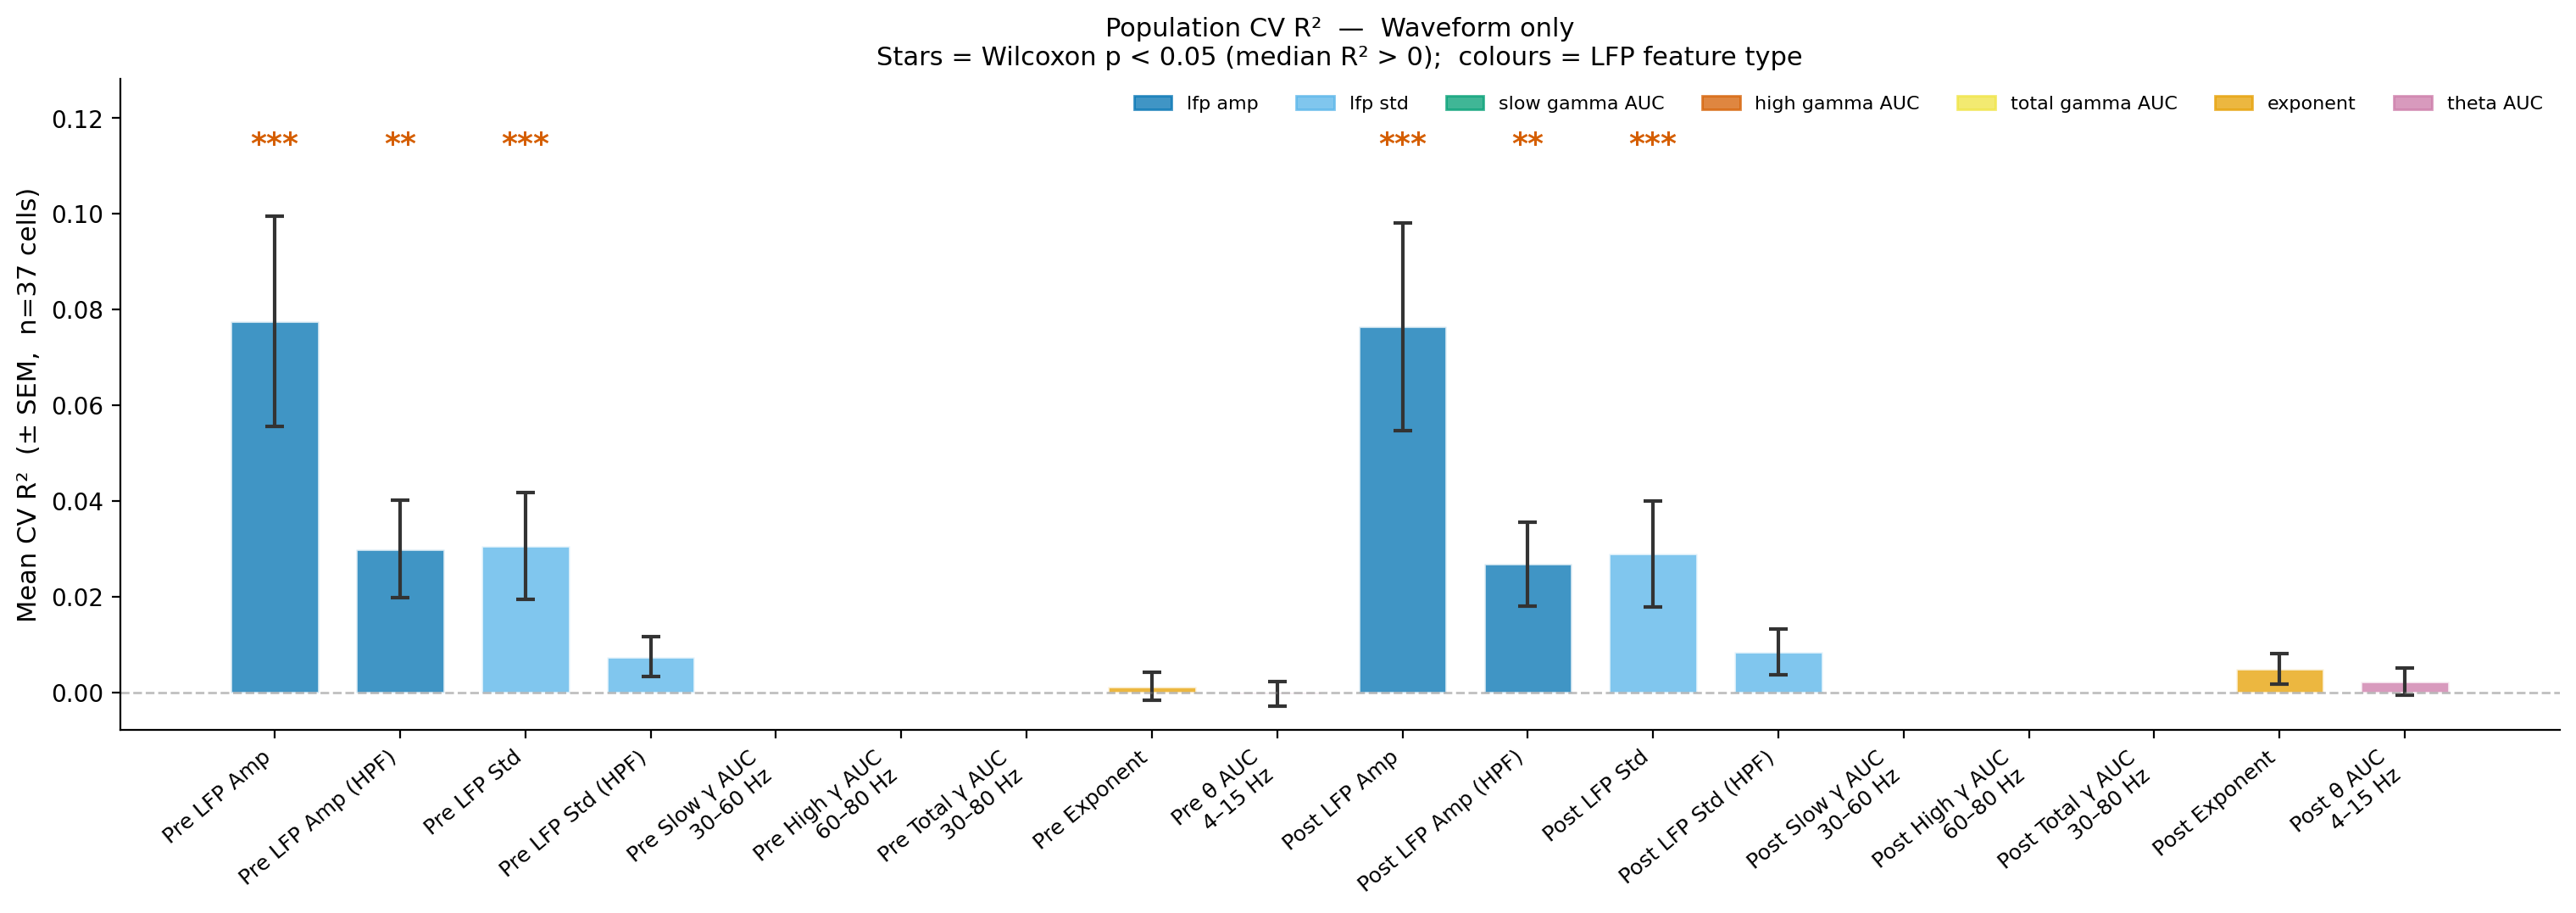

In [12]:
# ── 3d. R² summary — mean ± SEM per target with significance stars ─────────────
plot_r2_summary(r2_pop, df_r2, target_names, target_labels)

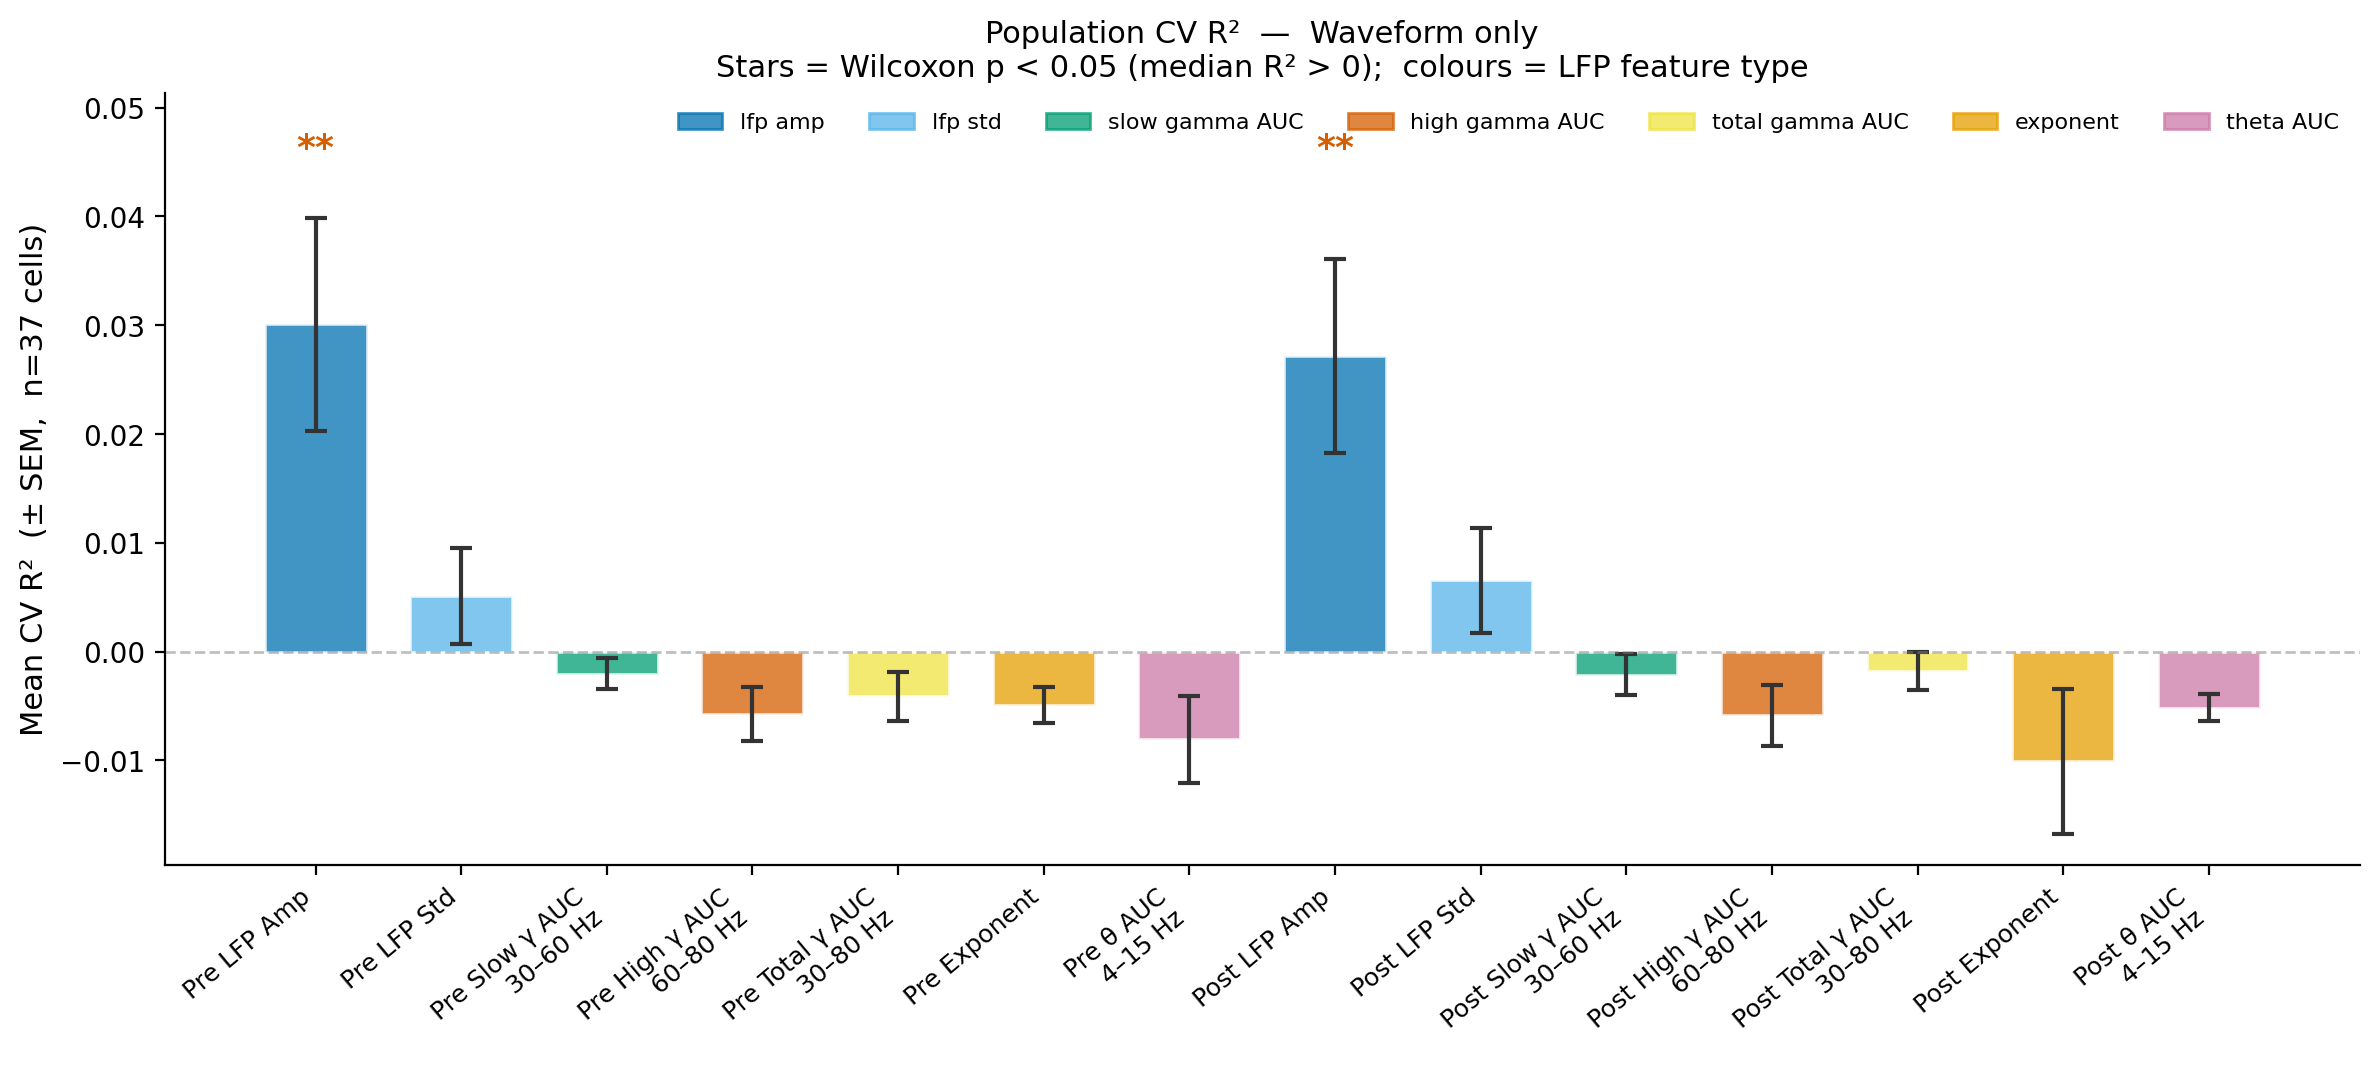

In [13]:
# ── 3d-psd. R² summary — single-PSD method (compare with sliding-window above)
plot_r2_summary(r2_pop_psd, df_r2_psd, target_names_psd, target_labels_psd)

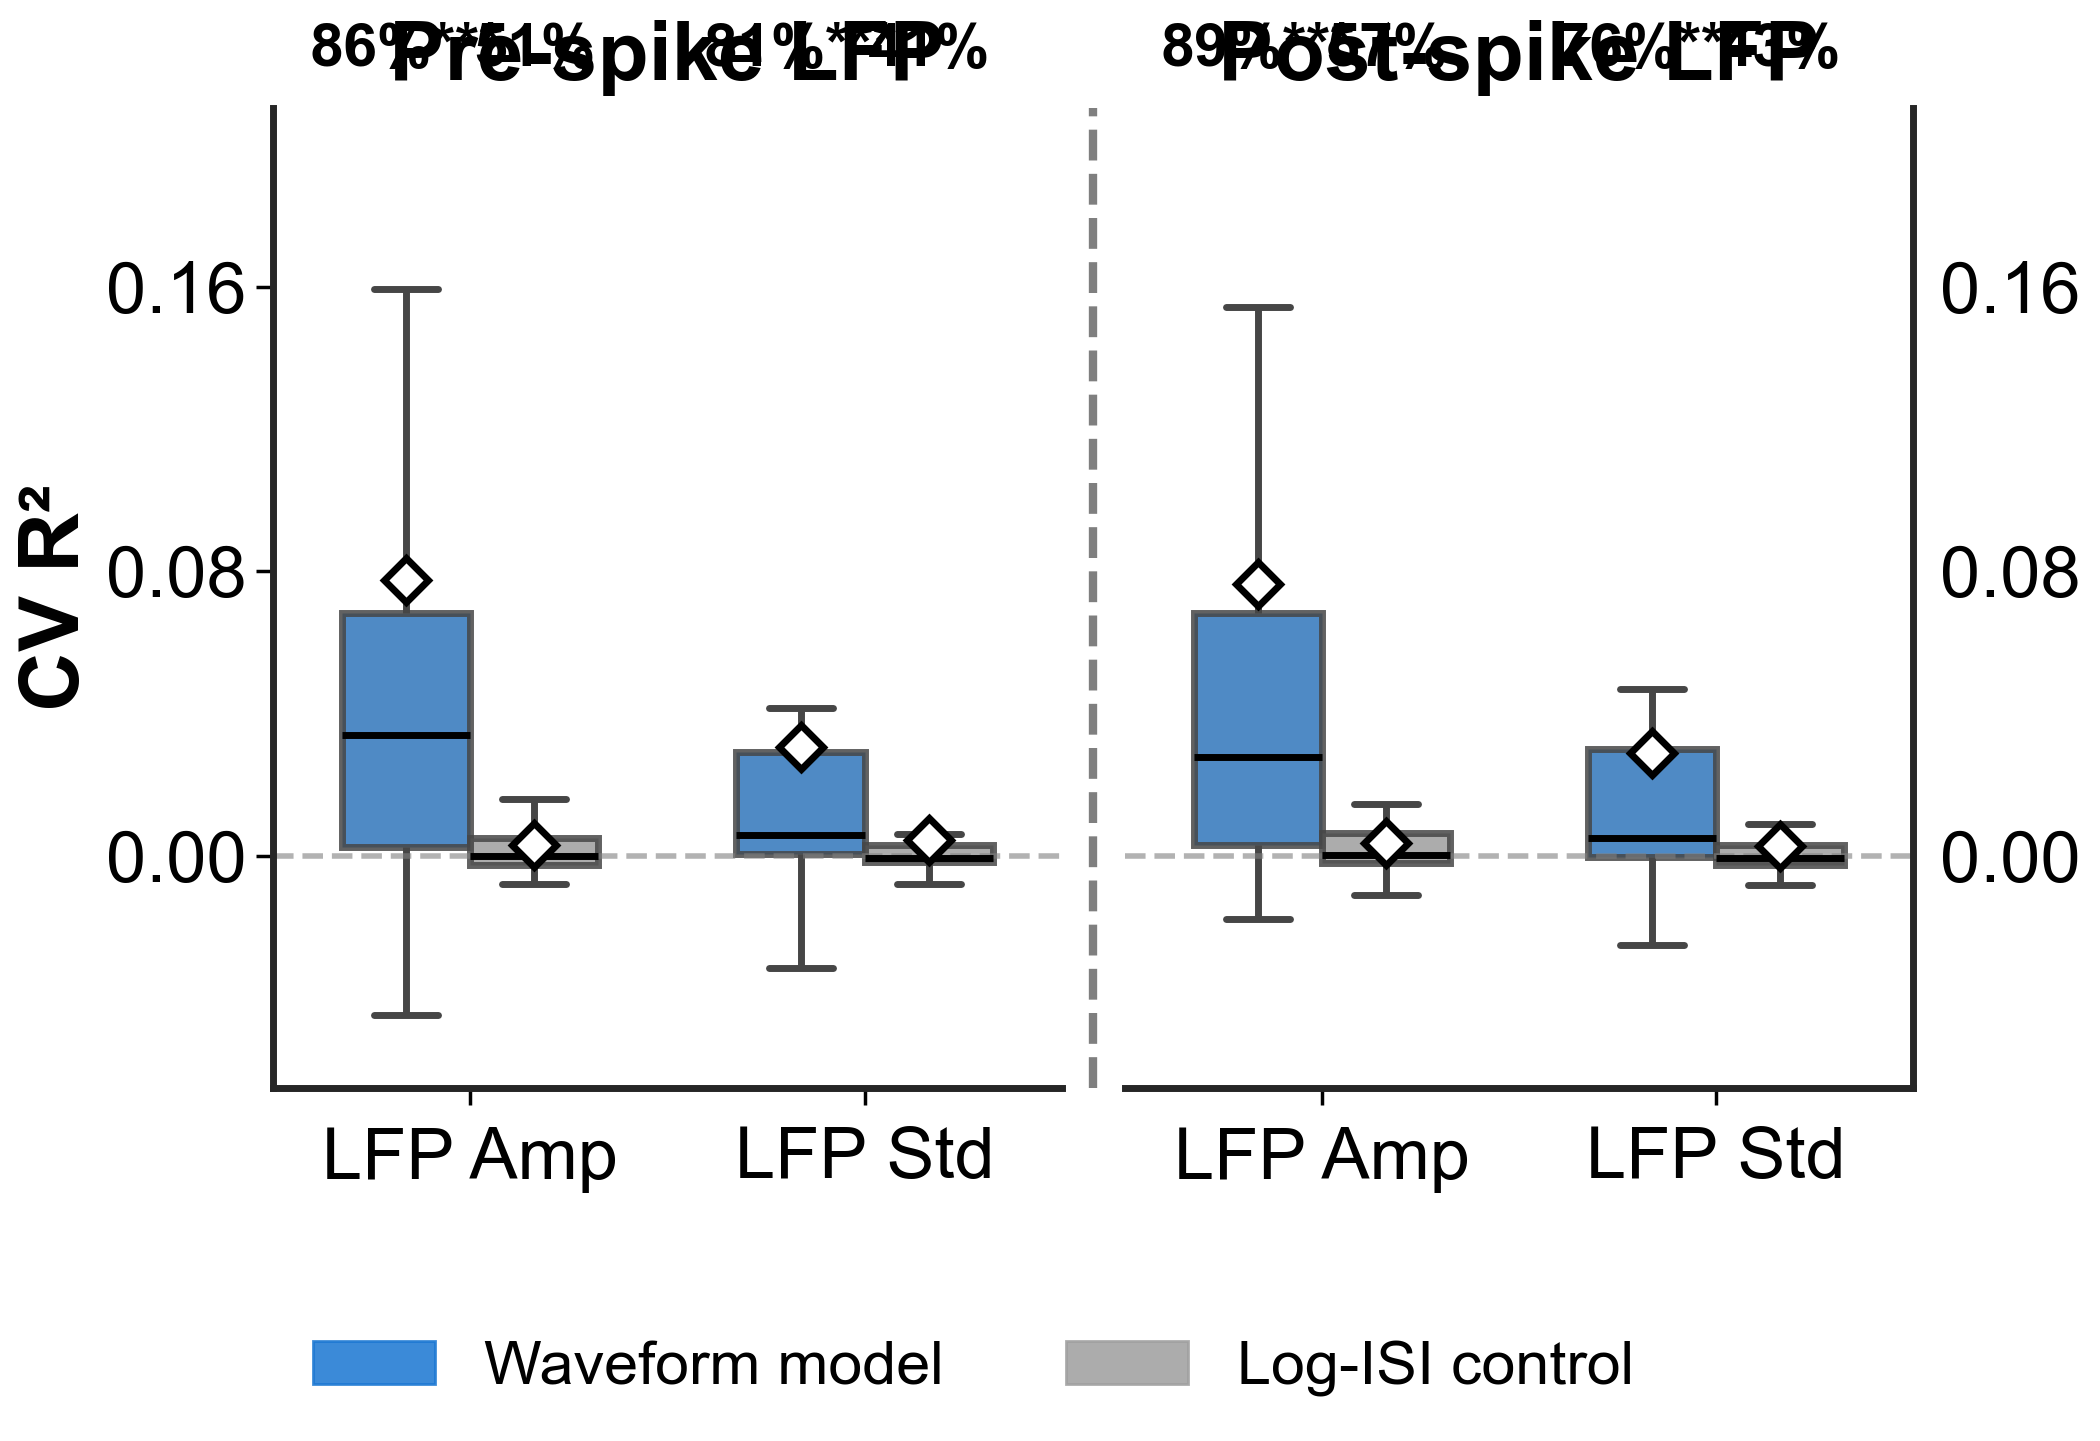

(<Figure size 1000x700 with 2 Axes>,
 array([<Axes: title={'center': 'Pre-spike LFP'}, ylabel='CV R²'>,
        <Axes: title={'center': 'Post-spike LFP'}>], dtype=object))

In [14]:
# ── 3e. R² boxplot — cartoony, core (non-HPF) targets only ───────────────────
import importlib, pop_ridge_utils
importlib.reload(pop_ridge_utils)
from pop_ridge_utils import plot_r2_summary_boxplot

plot_r2_summary_boxplot(r2_pop, sig_pop, df_r2, target_names, target_labels,
                        predictor_set='Waveform only')

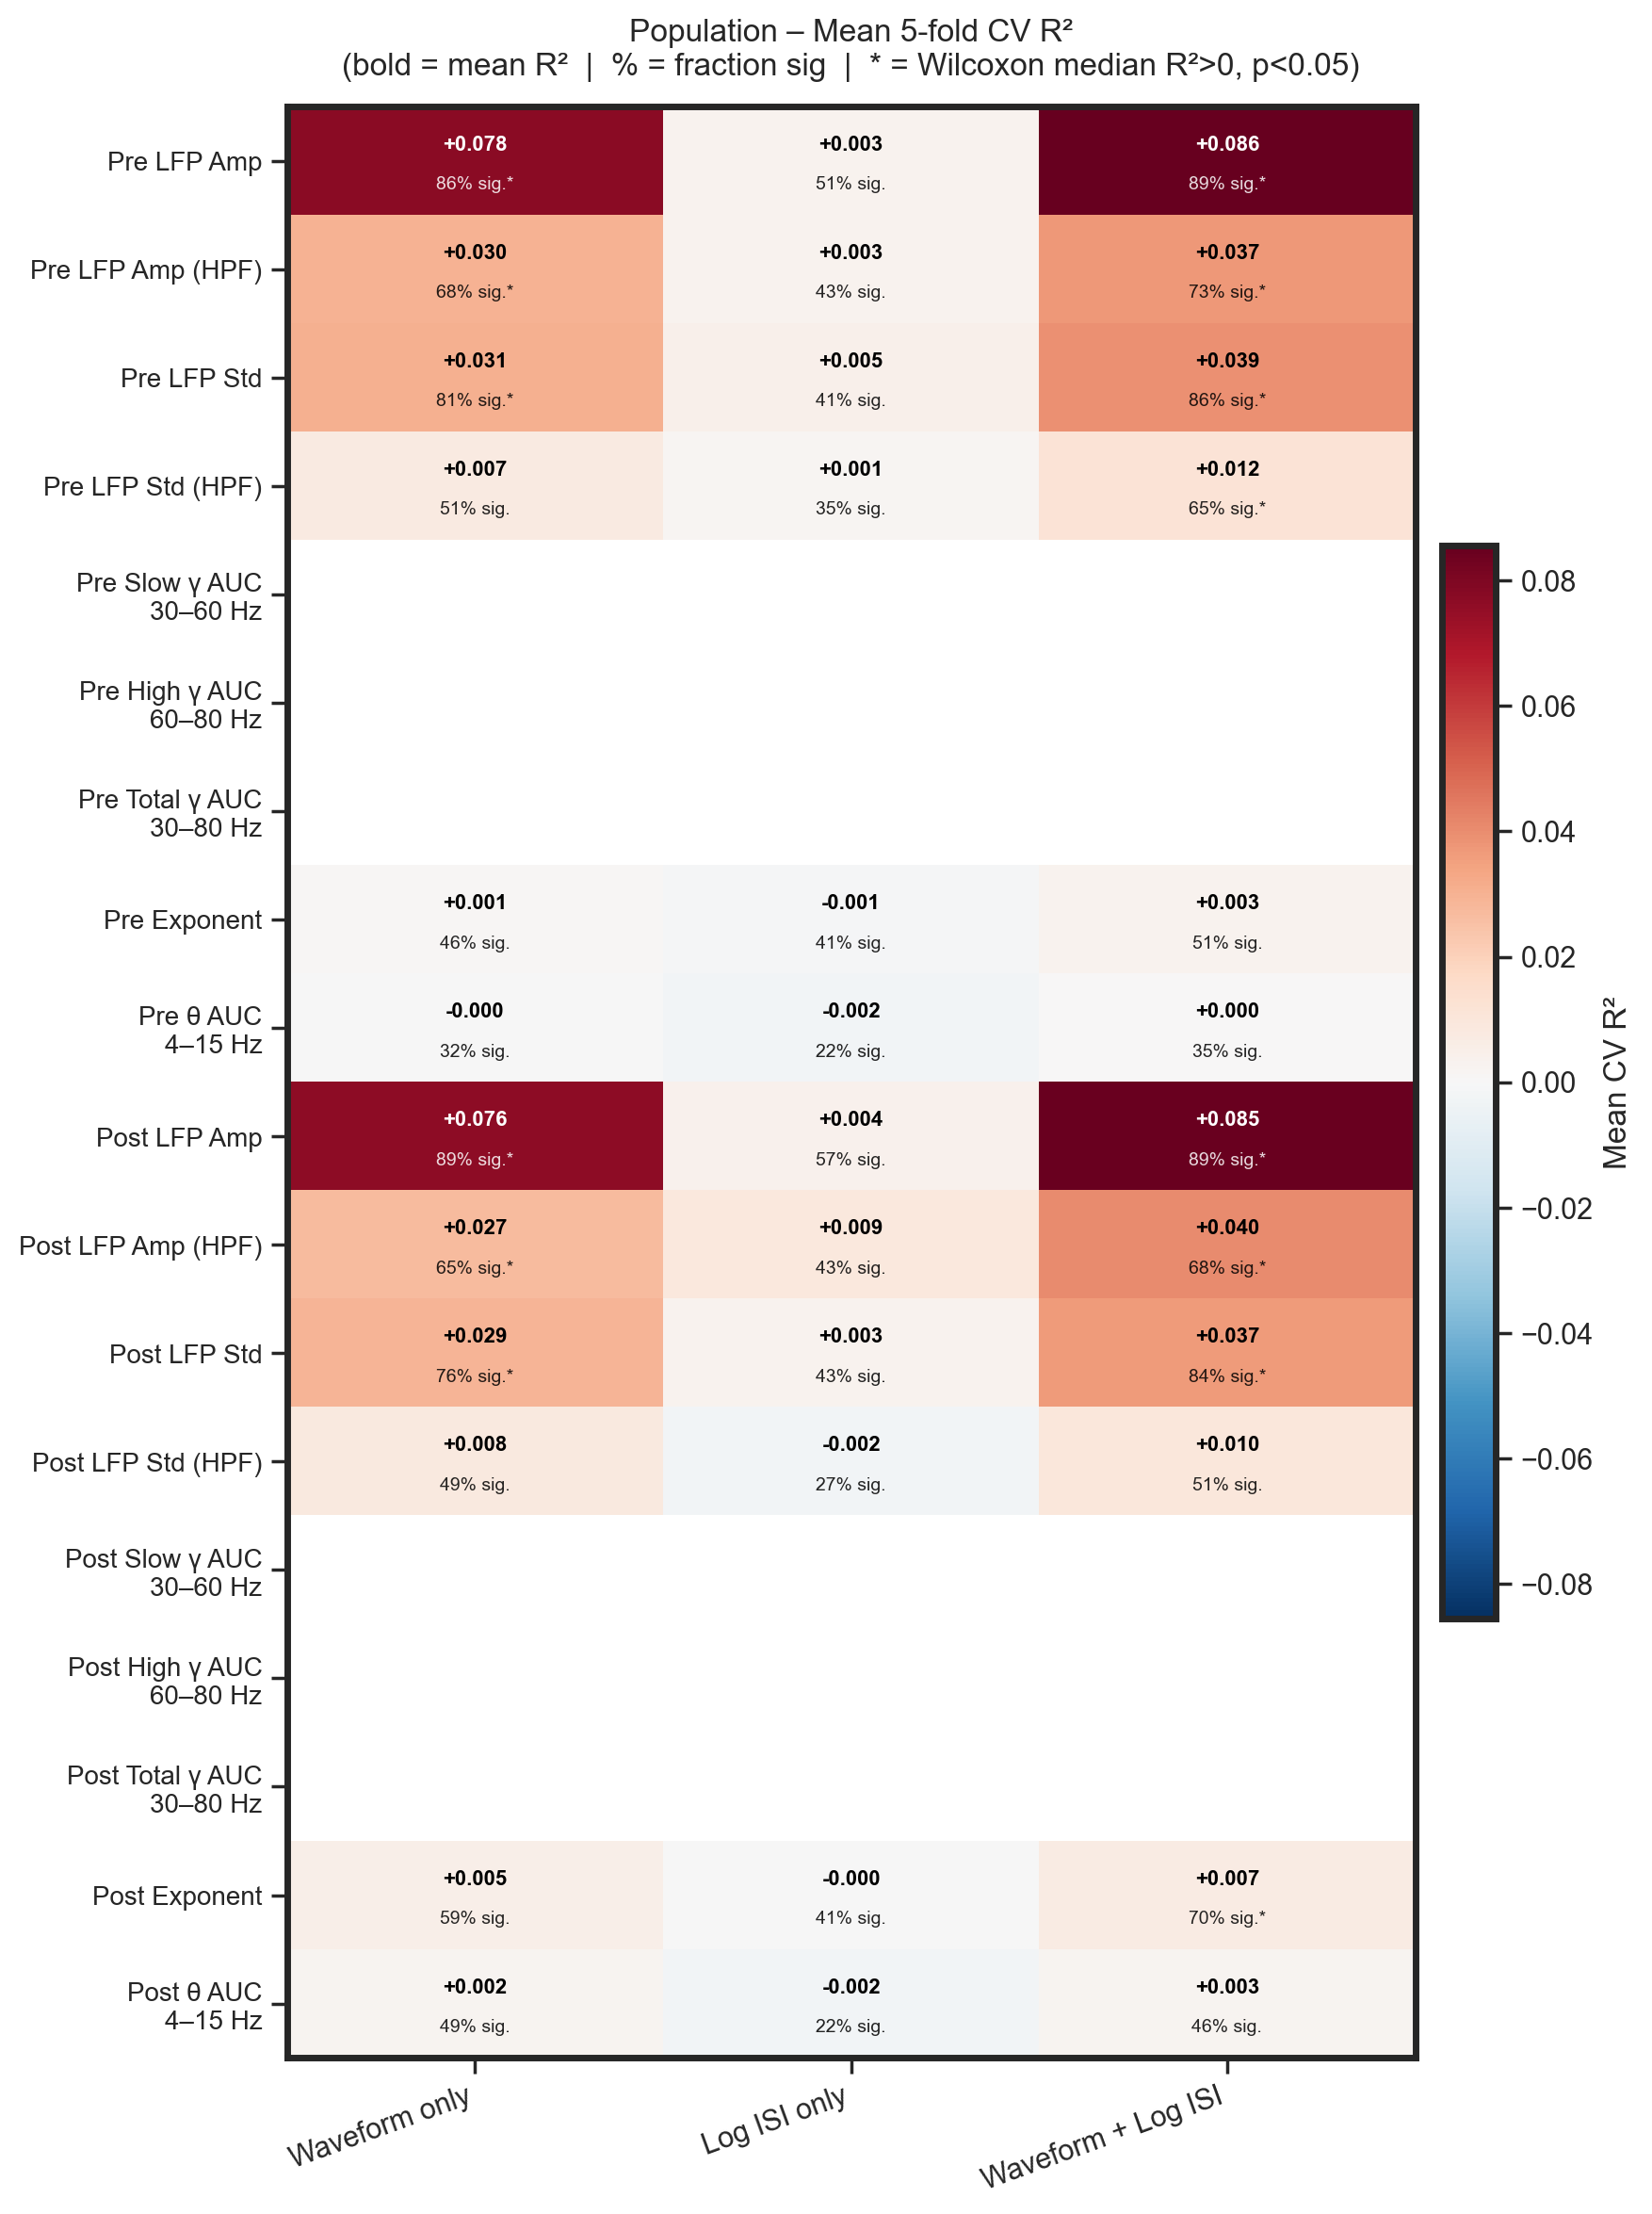

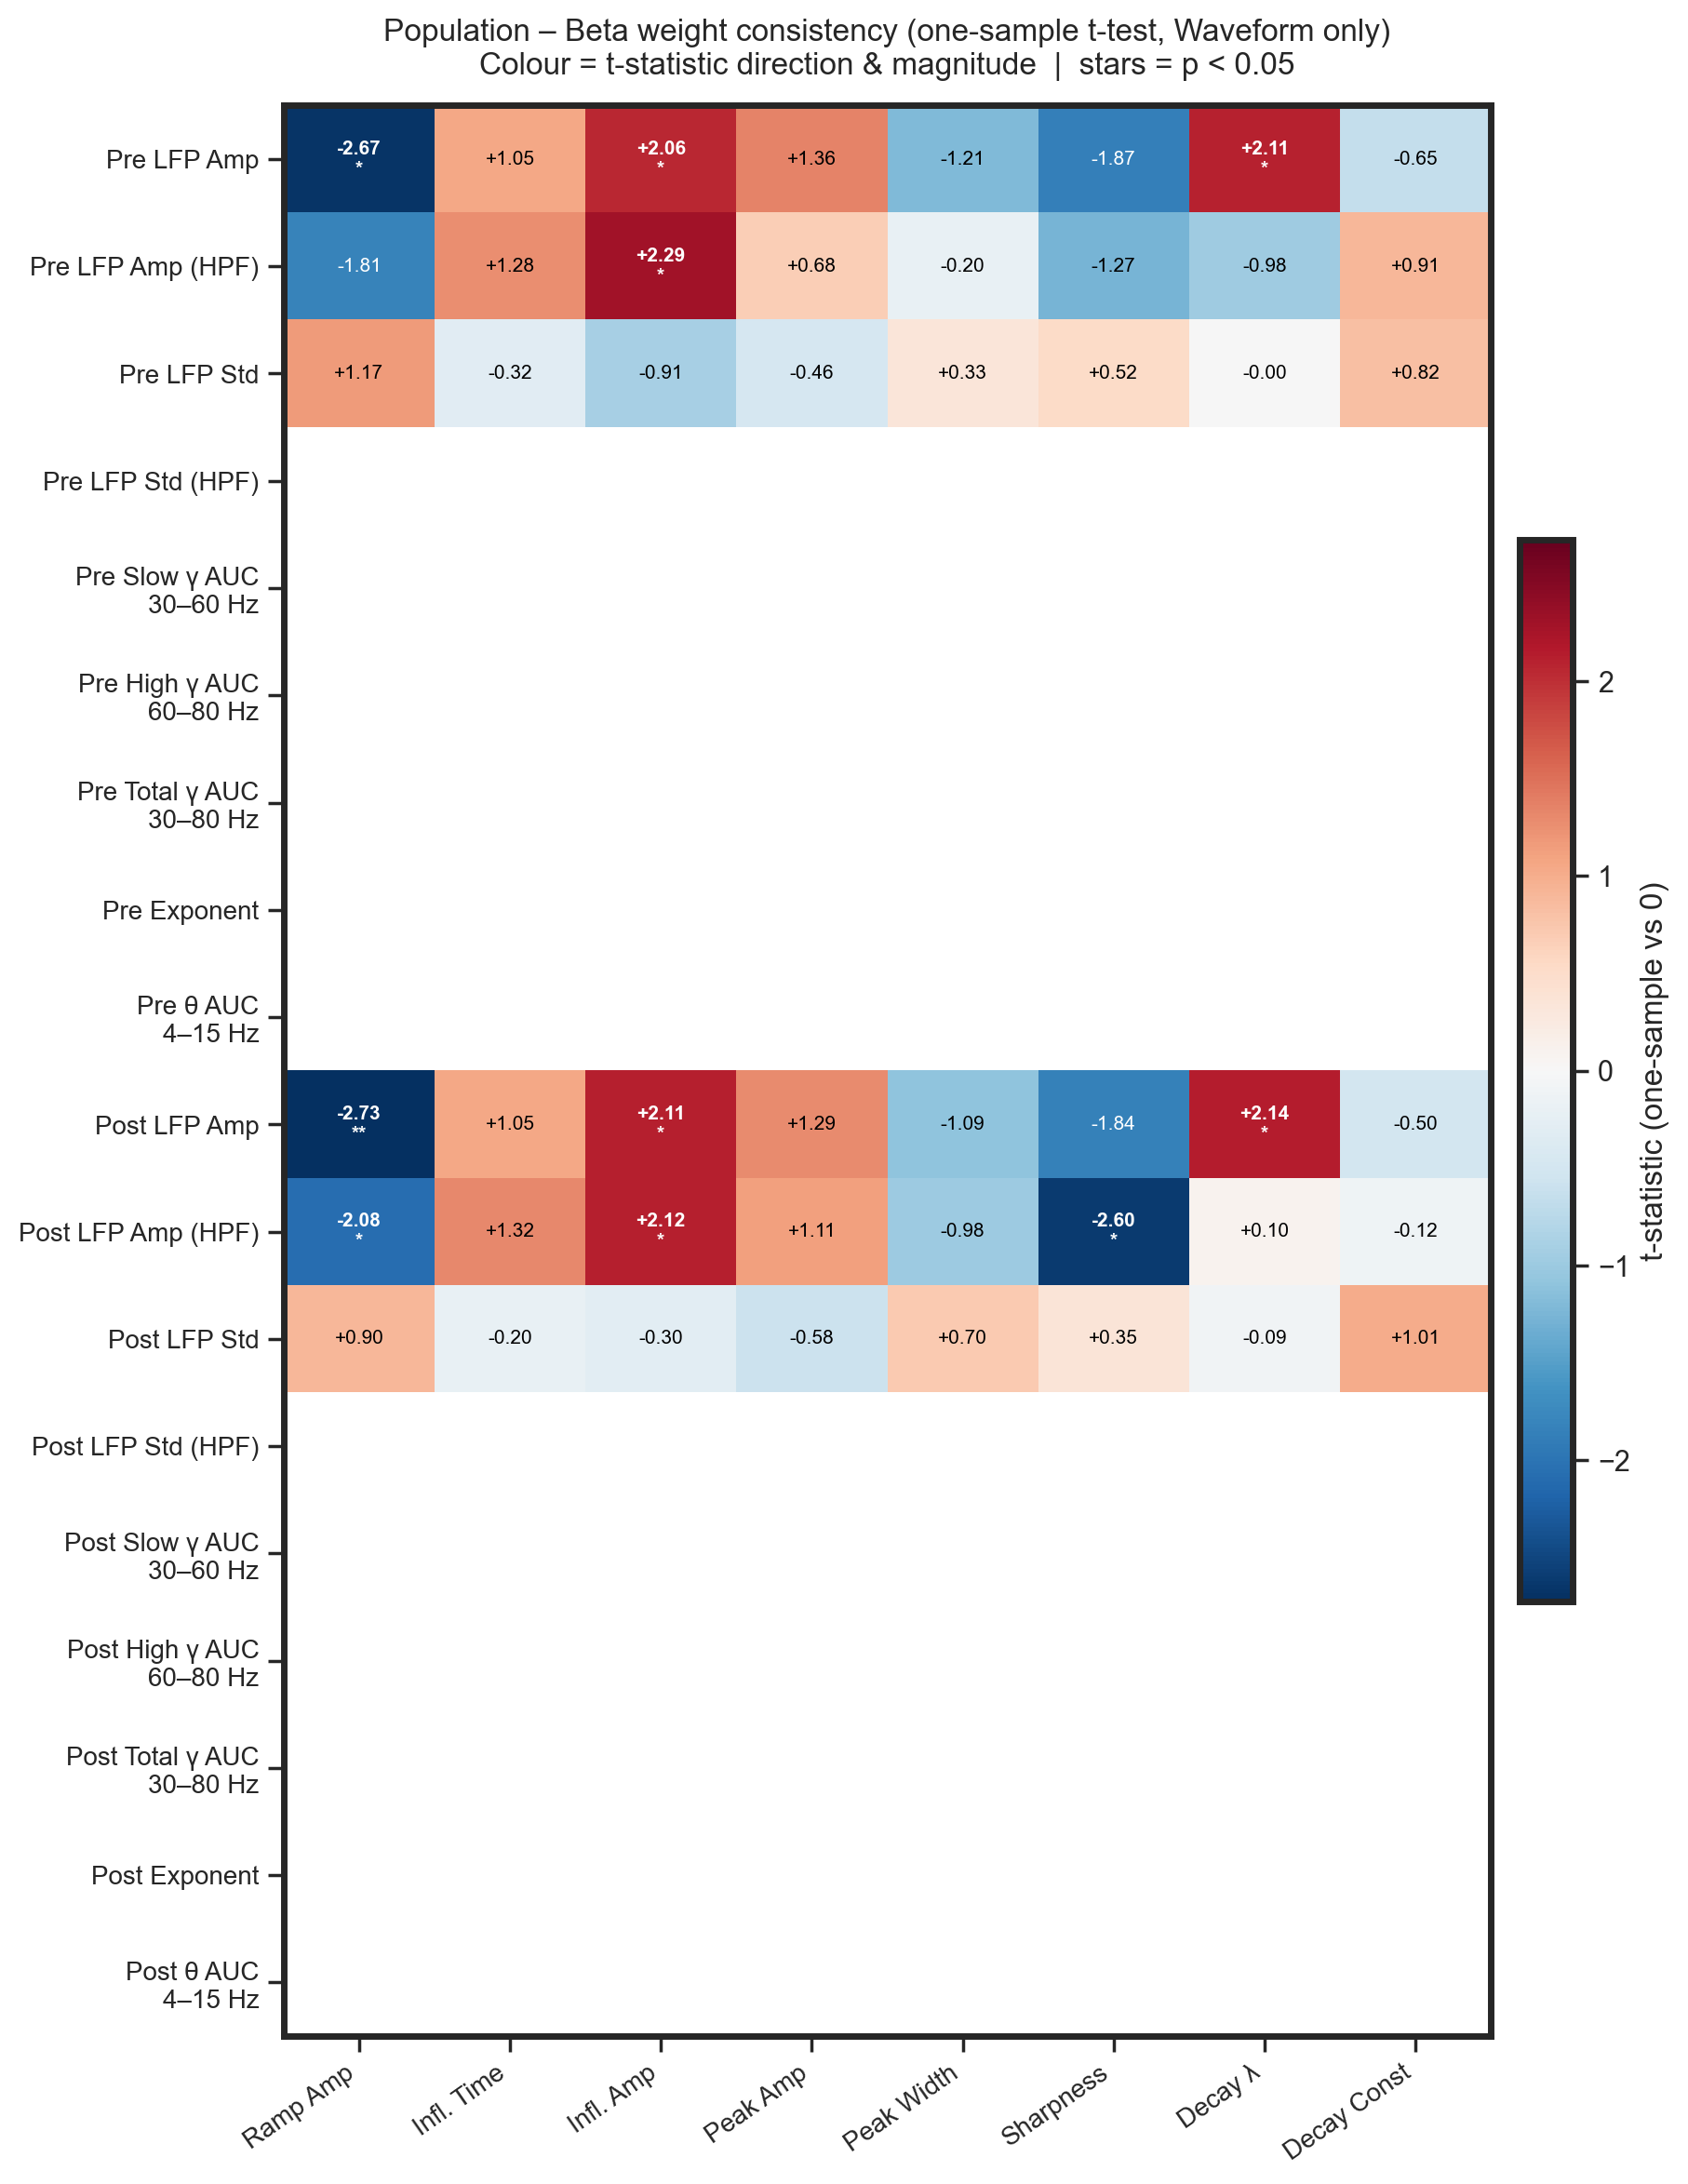

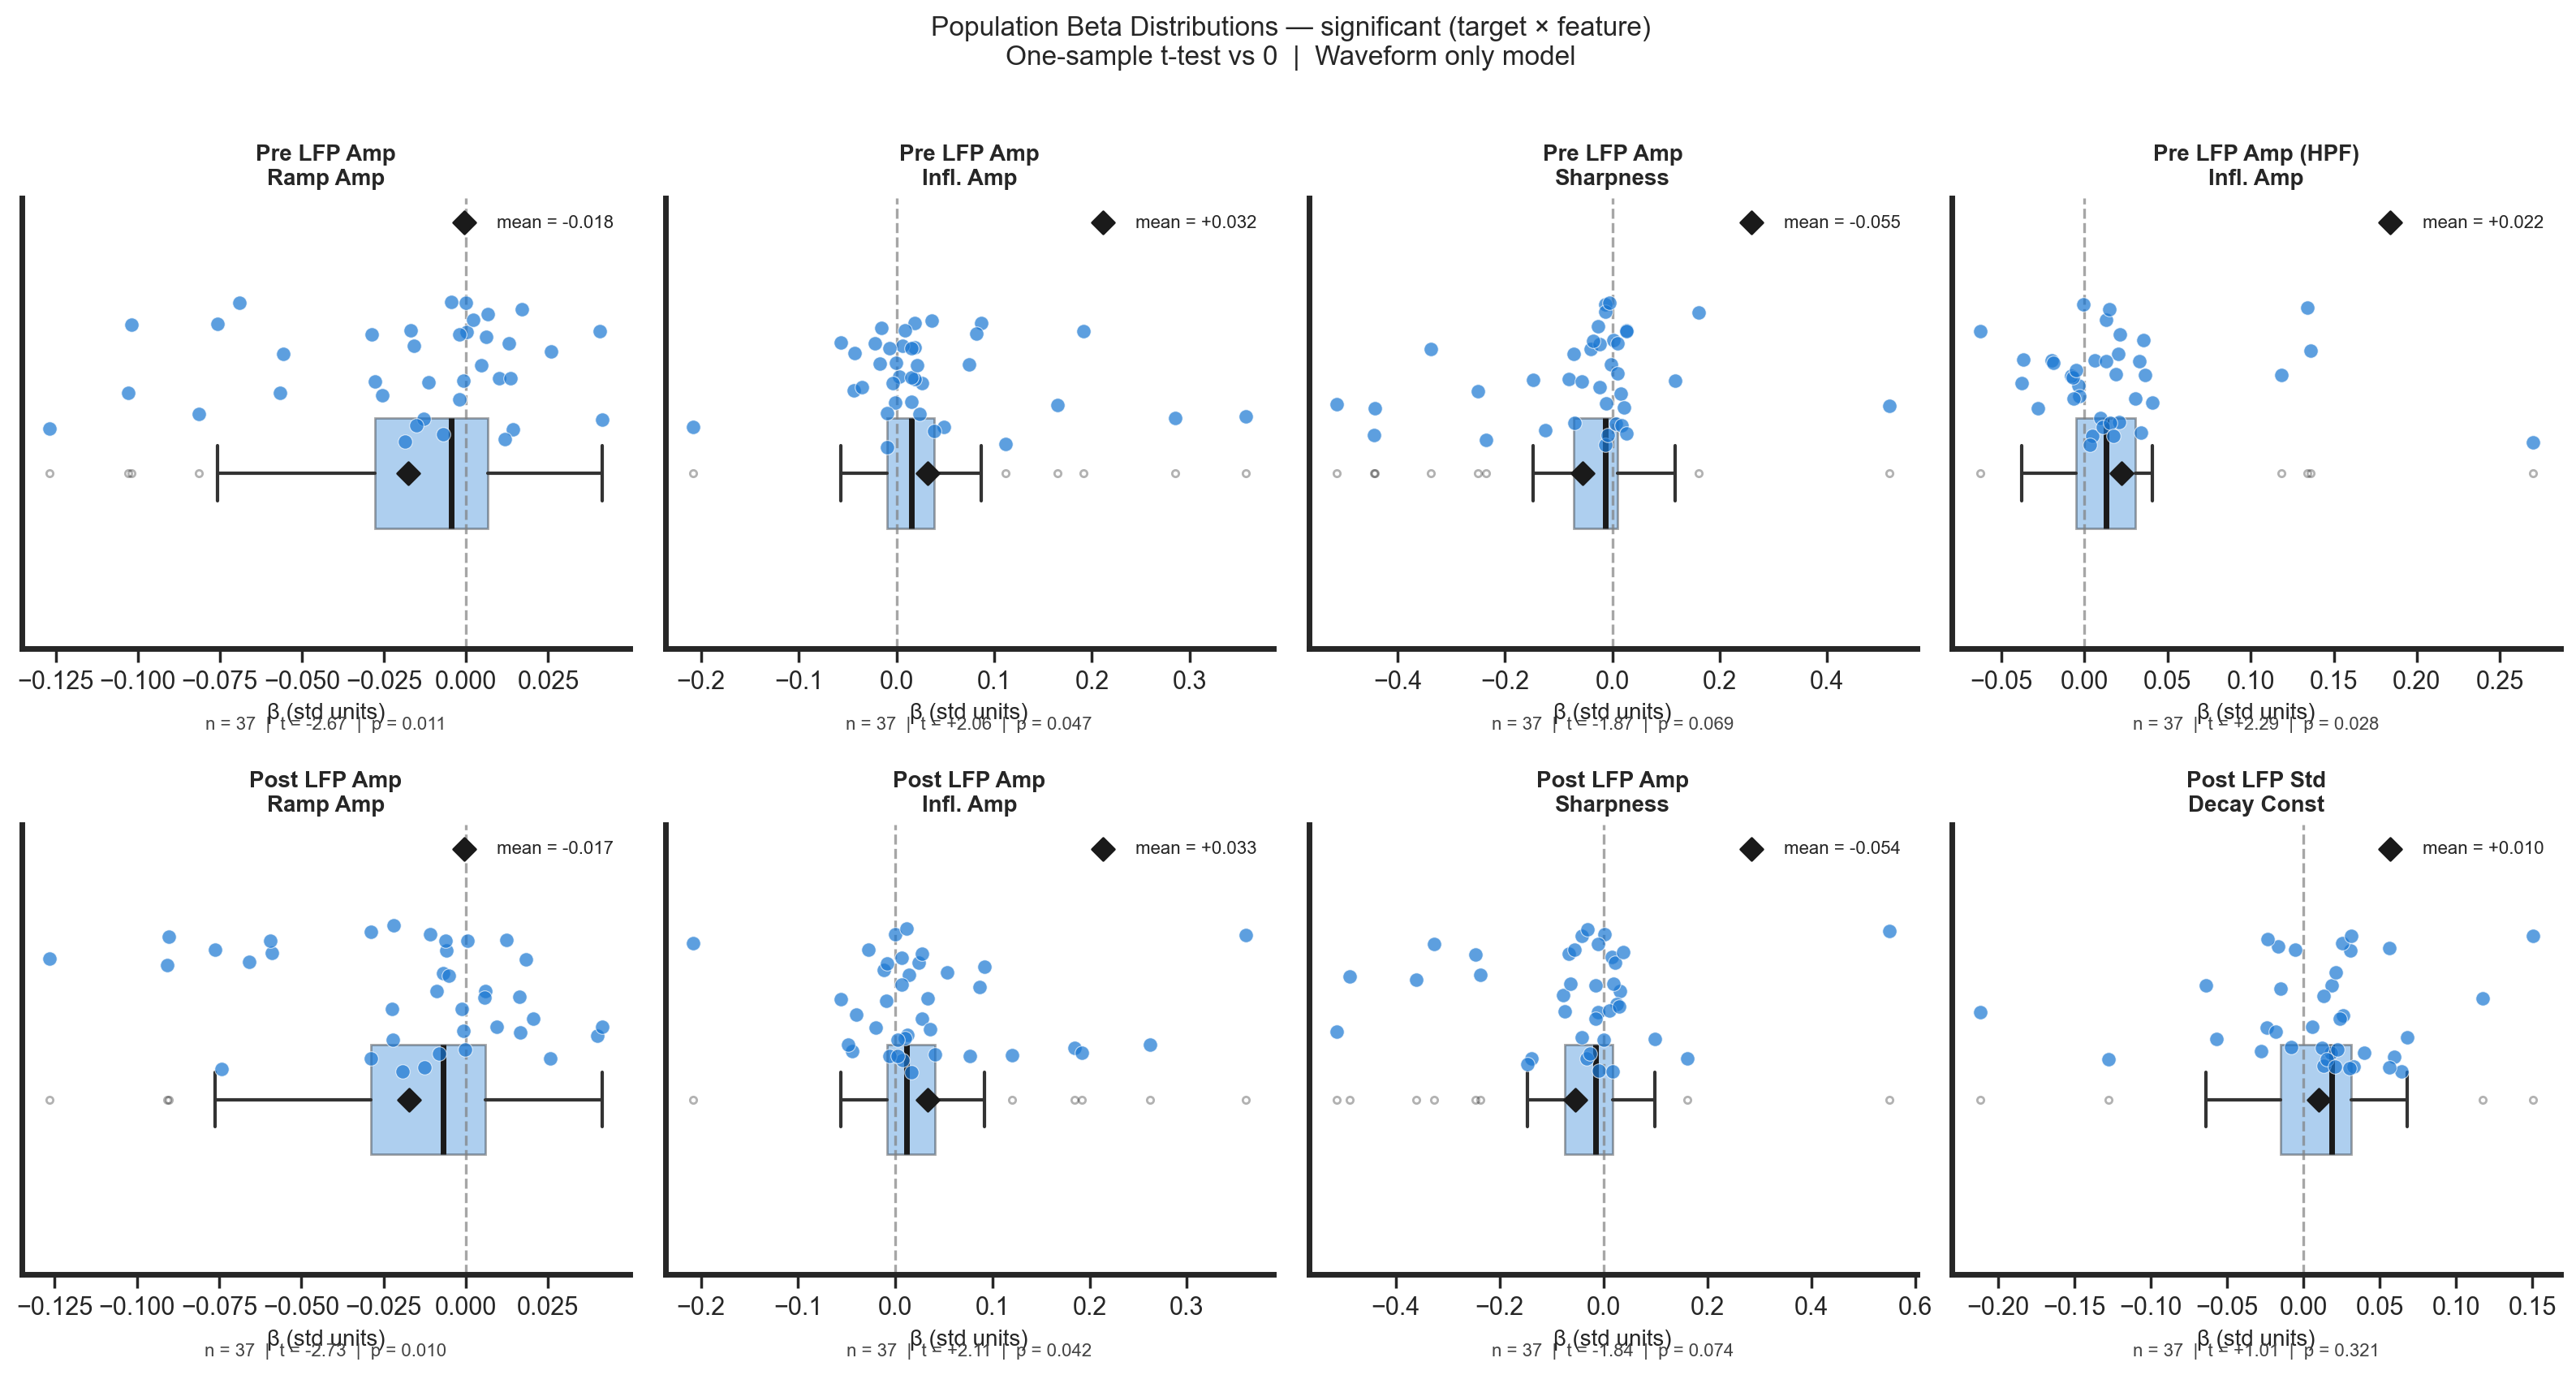

In [15]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
    df_frac=df_frac, df_r2=df_r2,
)

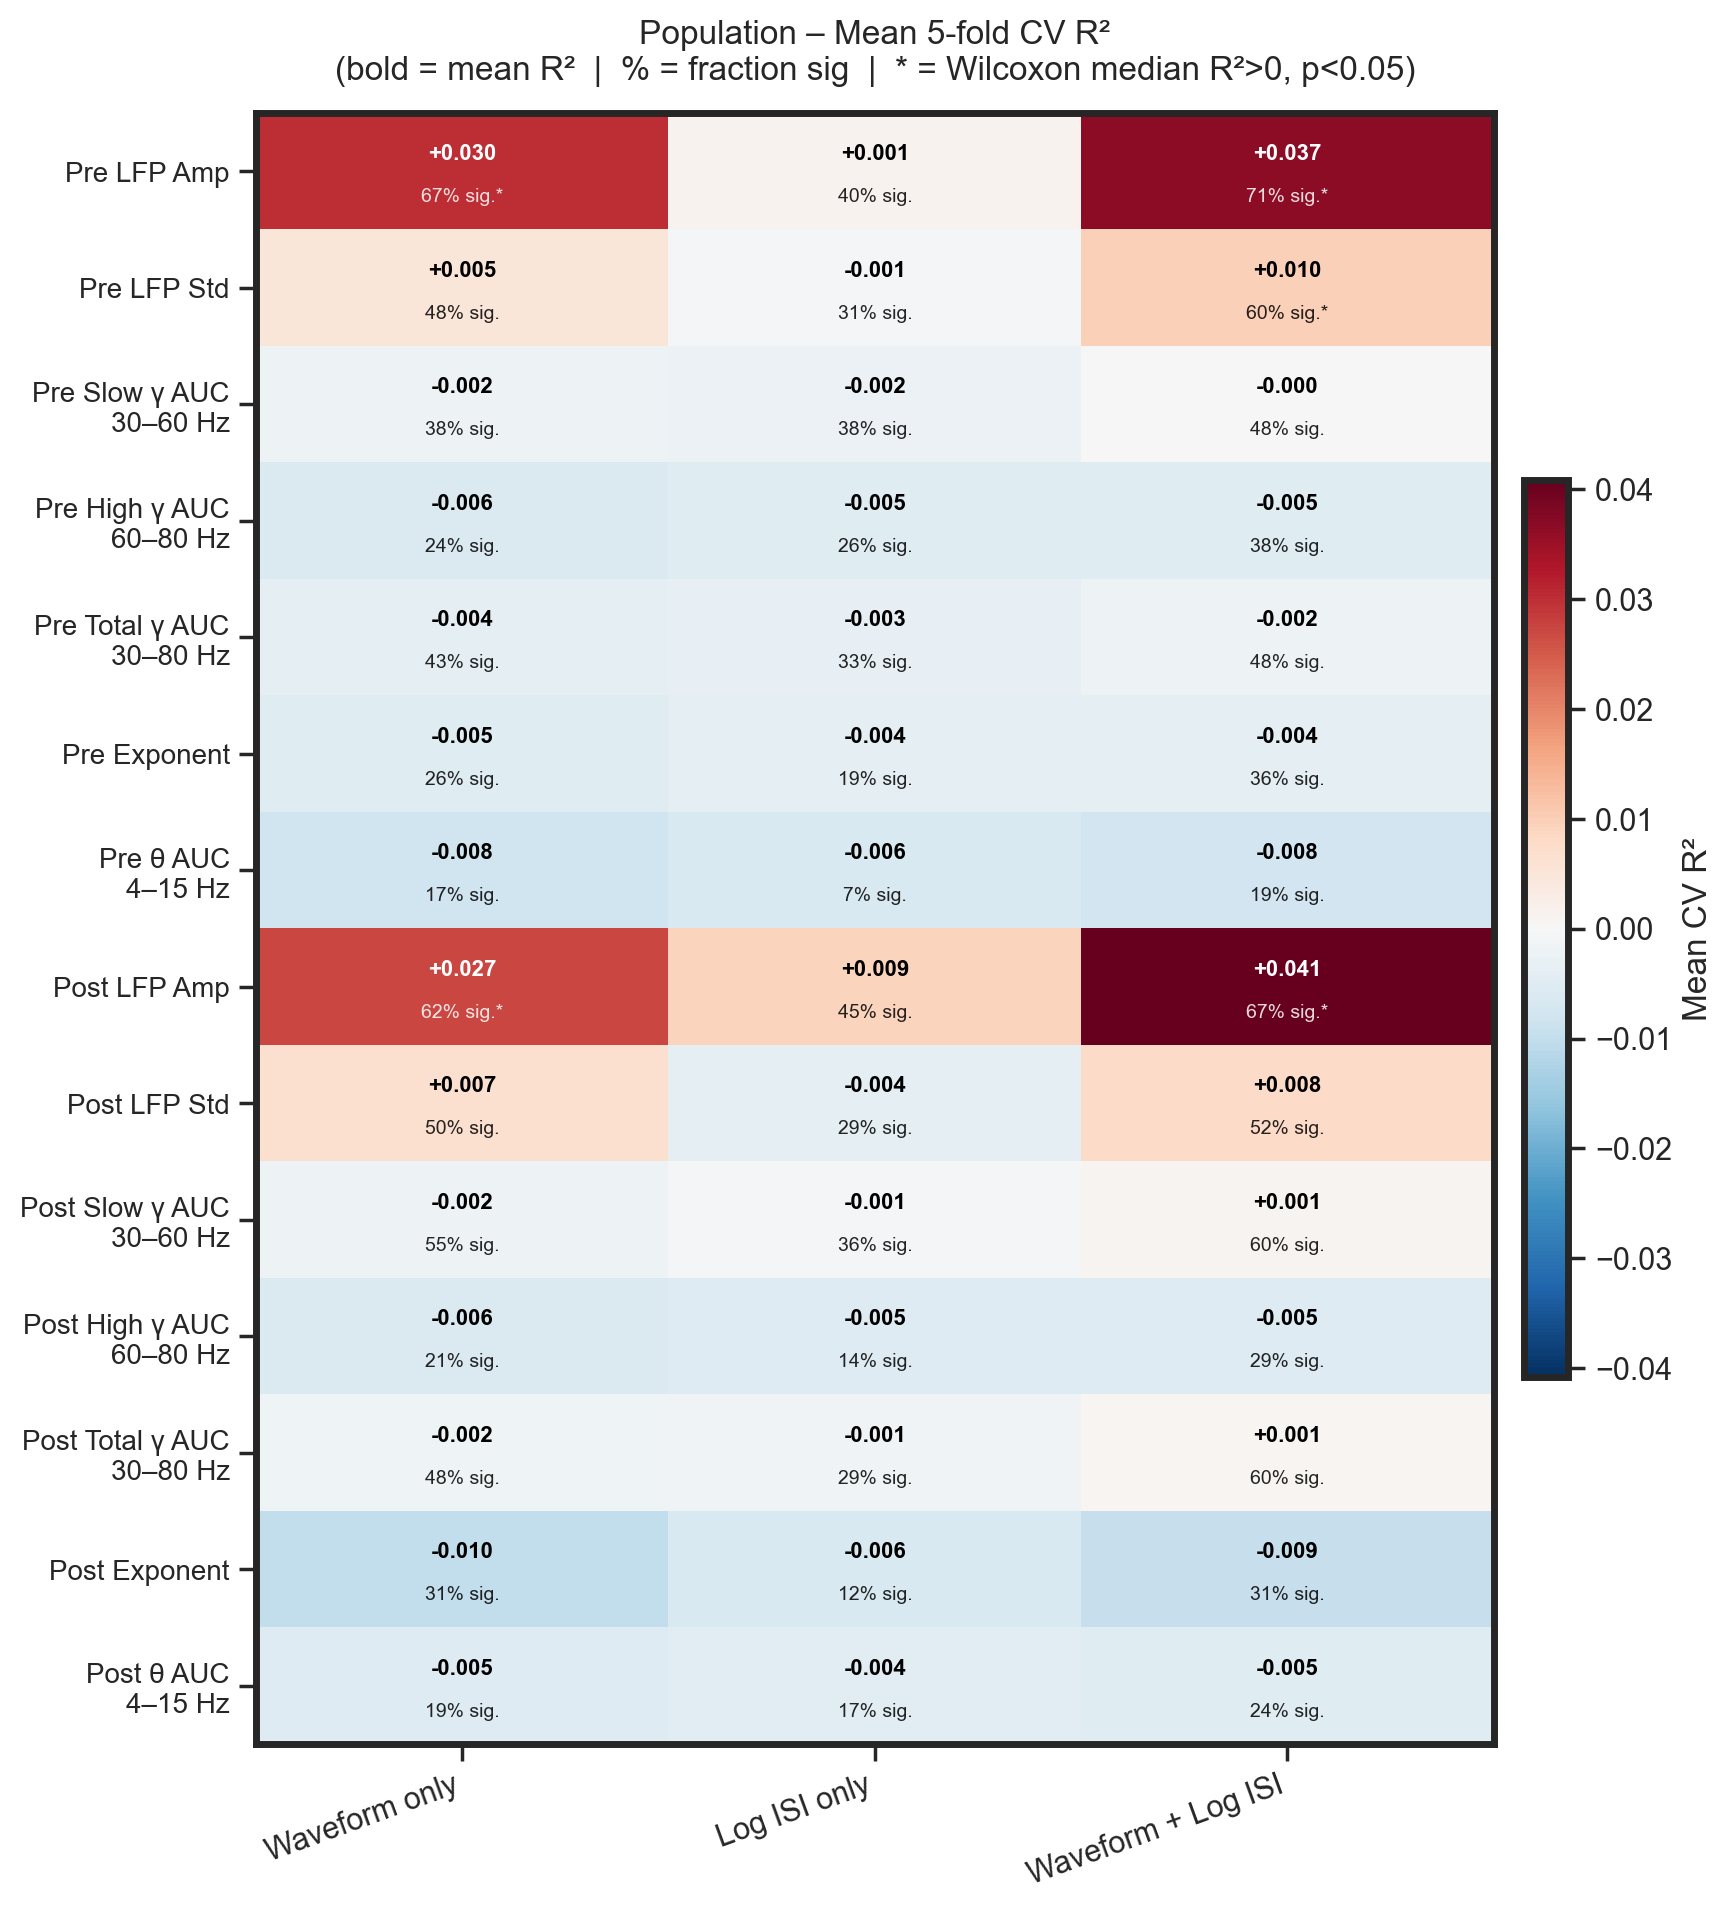

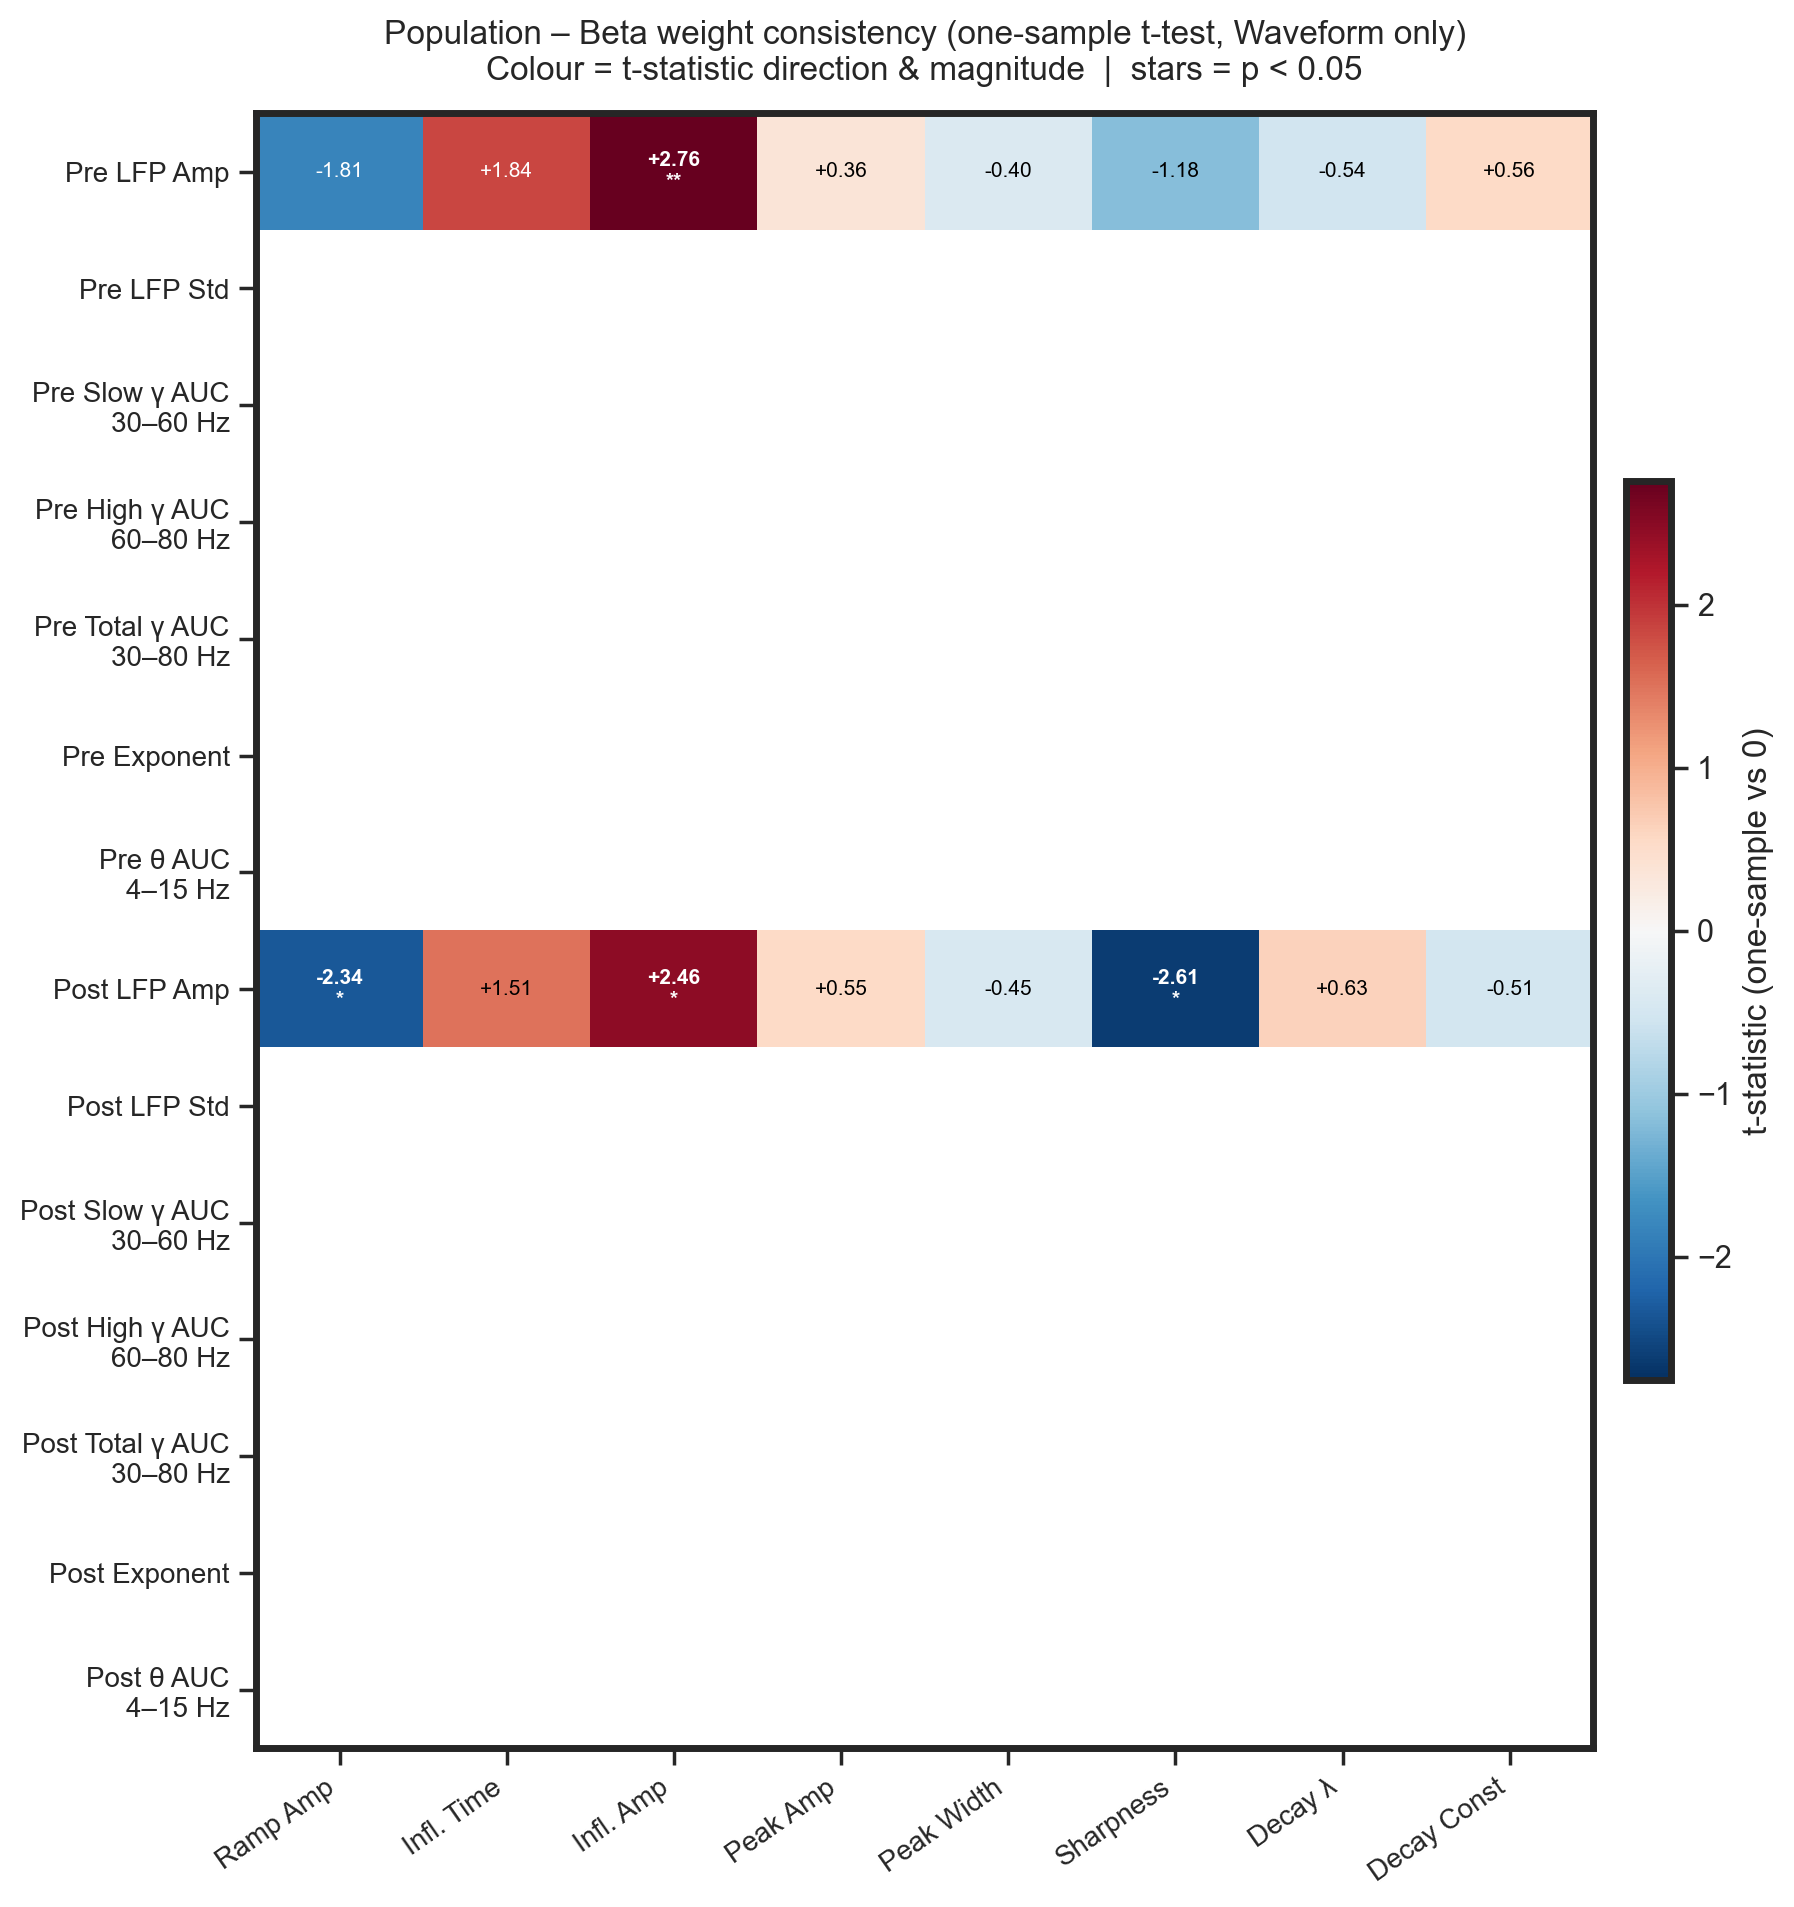

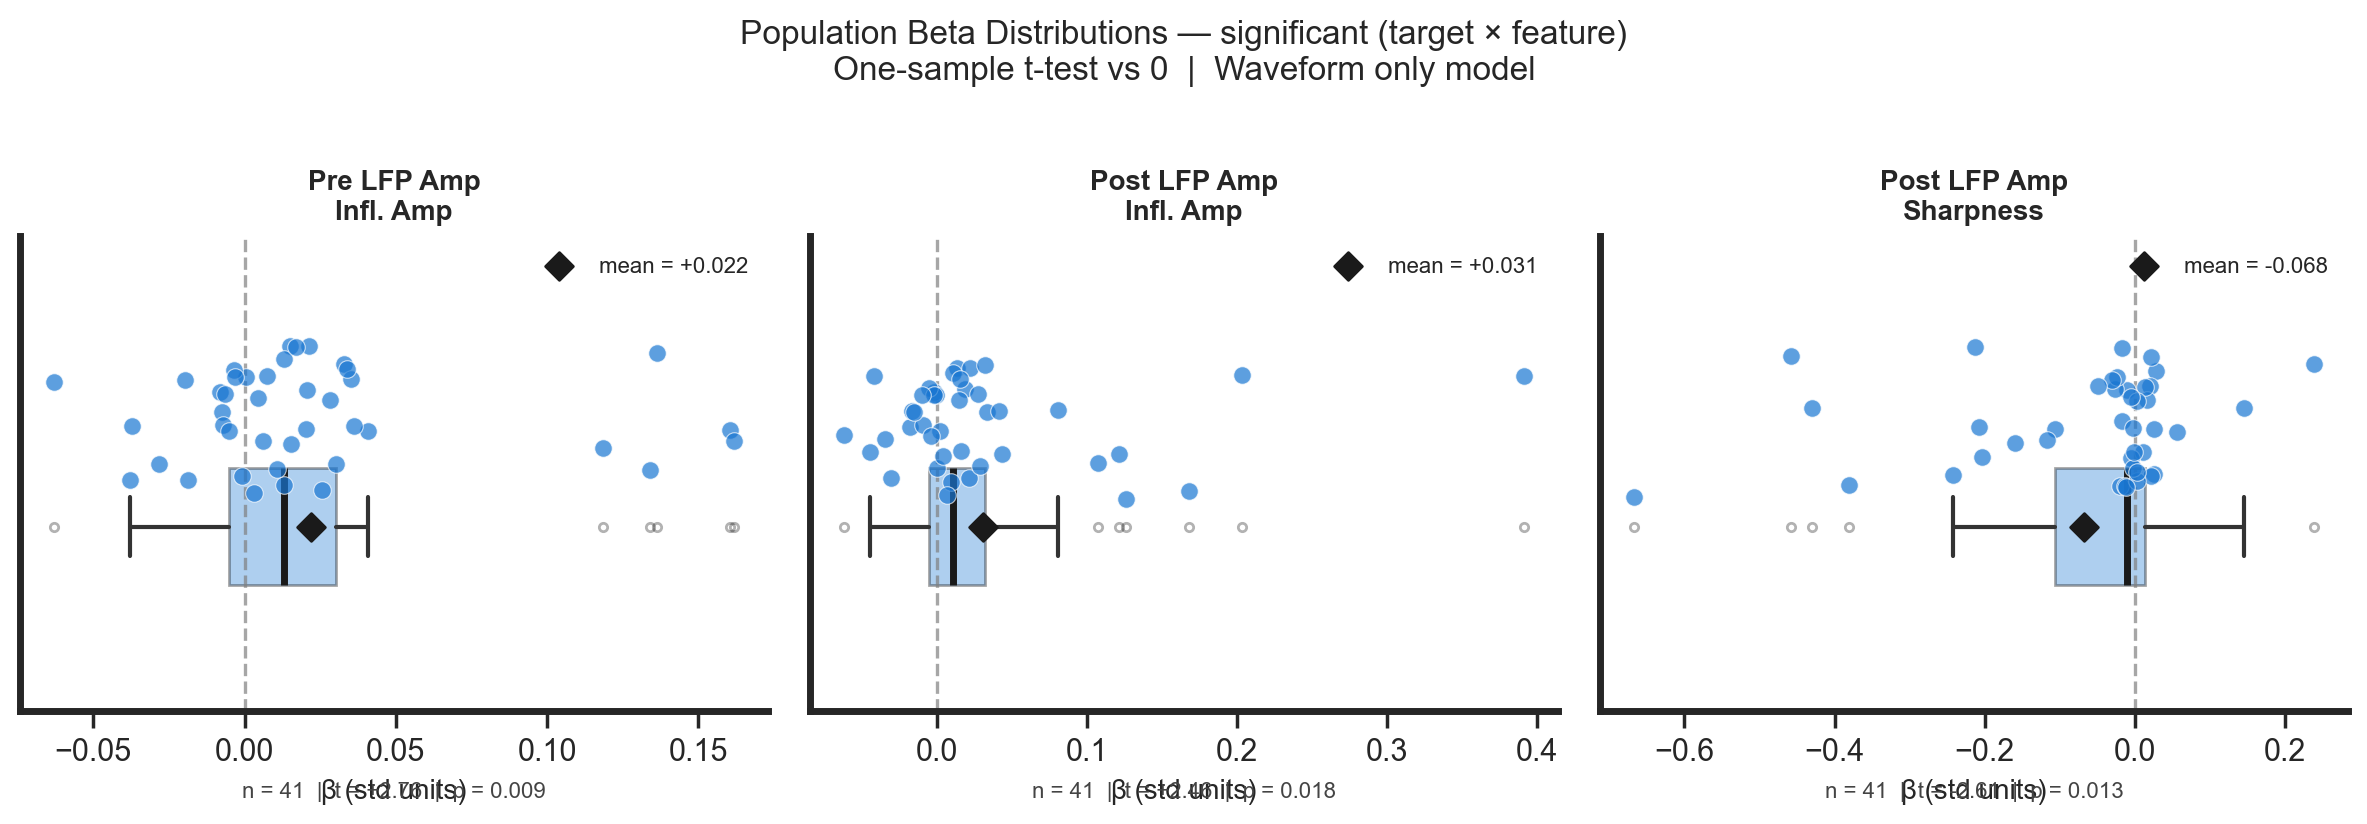

In [16]:
# ── 4-psd. R² heatmap + betas — single-PSD method ───────────────────────────
mean_r2_psd, frac_sig_psd, mean_beta_mat_psd, sig_beta_mat_psd = plot_population_results(
    r2_pop_psd, sig_pop_psd, beta_pop_psd, df_tests_psd,
    target_names_psd, target_labels_psd, predictor_sets_psd,
    df_frac=df_frac_psd, df_r2=df_r2_psd,
)

## 4. Visualisations

R² heatmap (targets × predictor sets), mean beta weight heatmap, per-cell R² distributions, and per-cell beta distributions. Stars on beta heatmap = significant Wilcoxon on that (target × feature) pair (p < 0.05, assessed within each target).

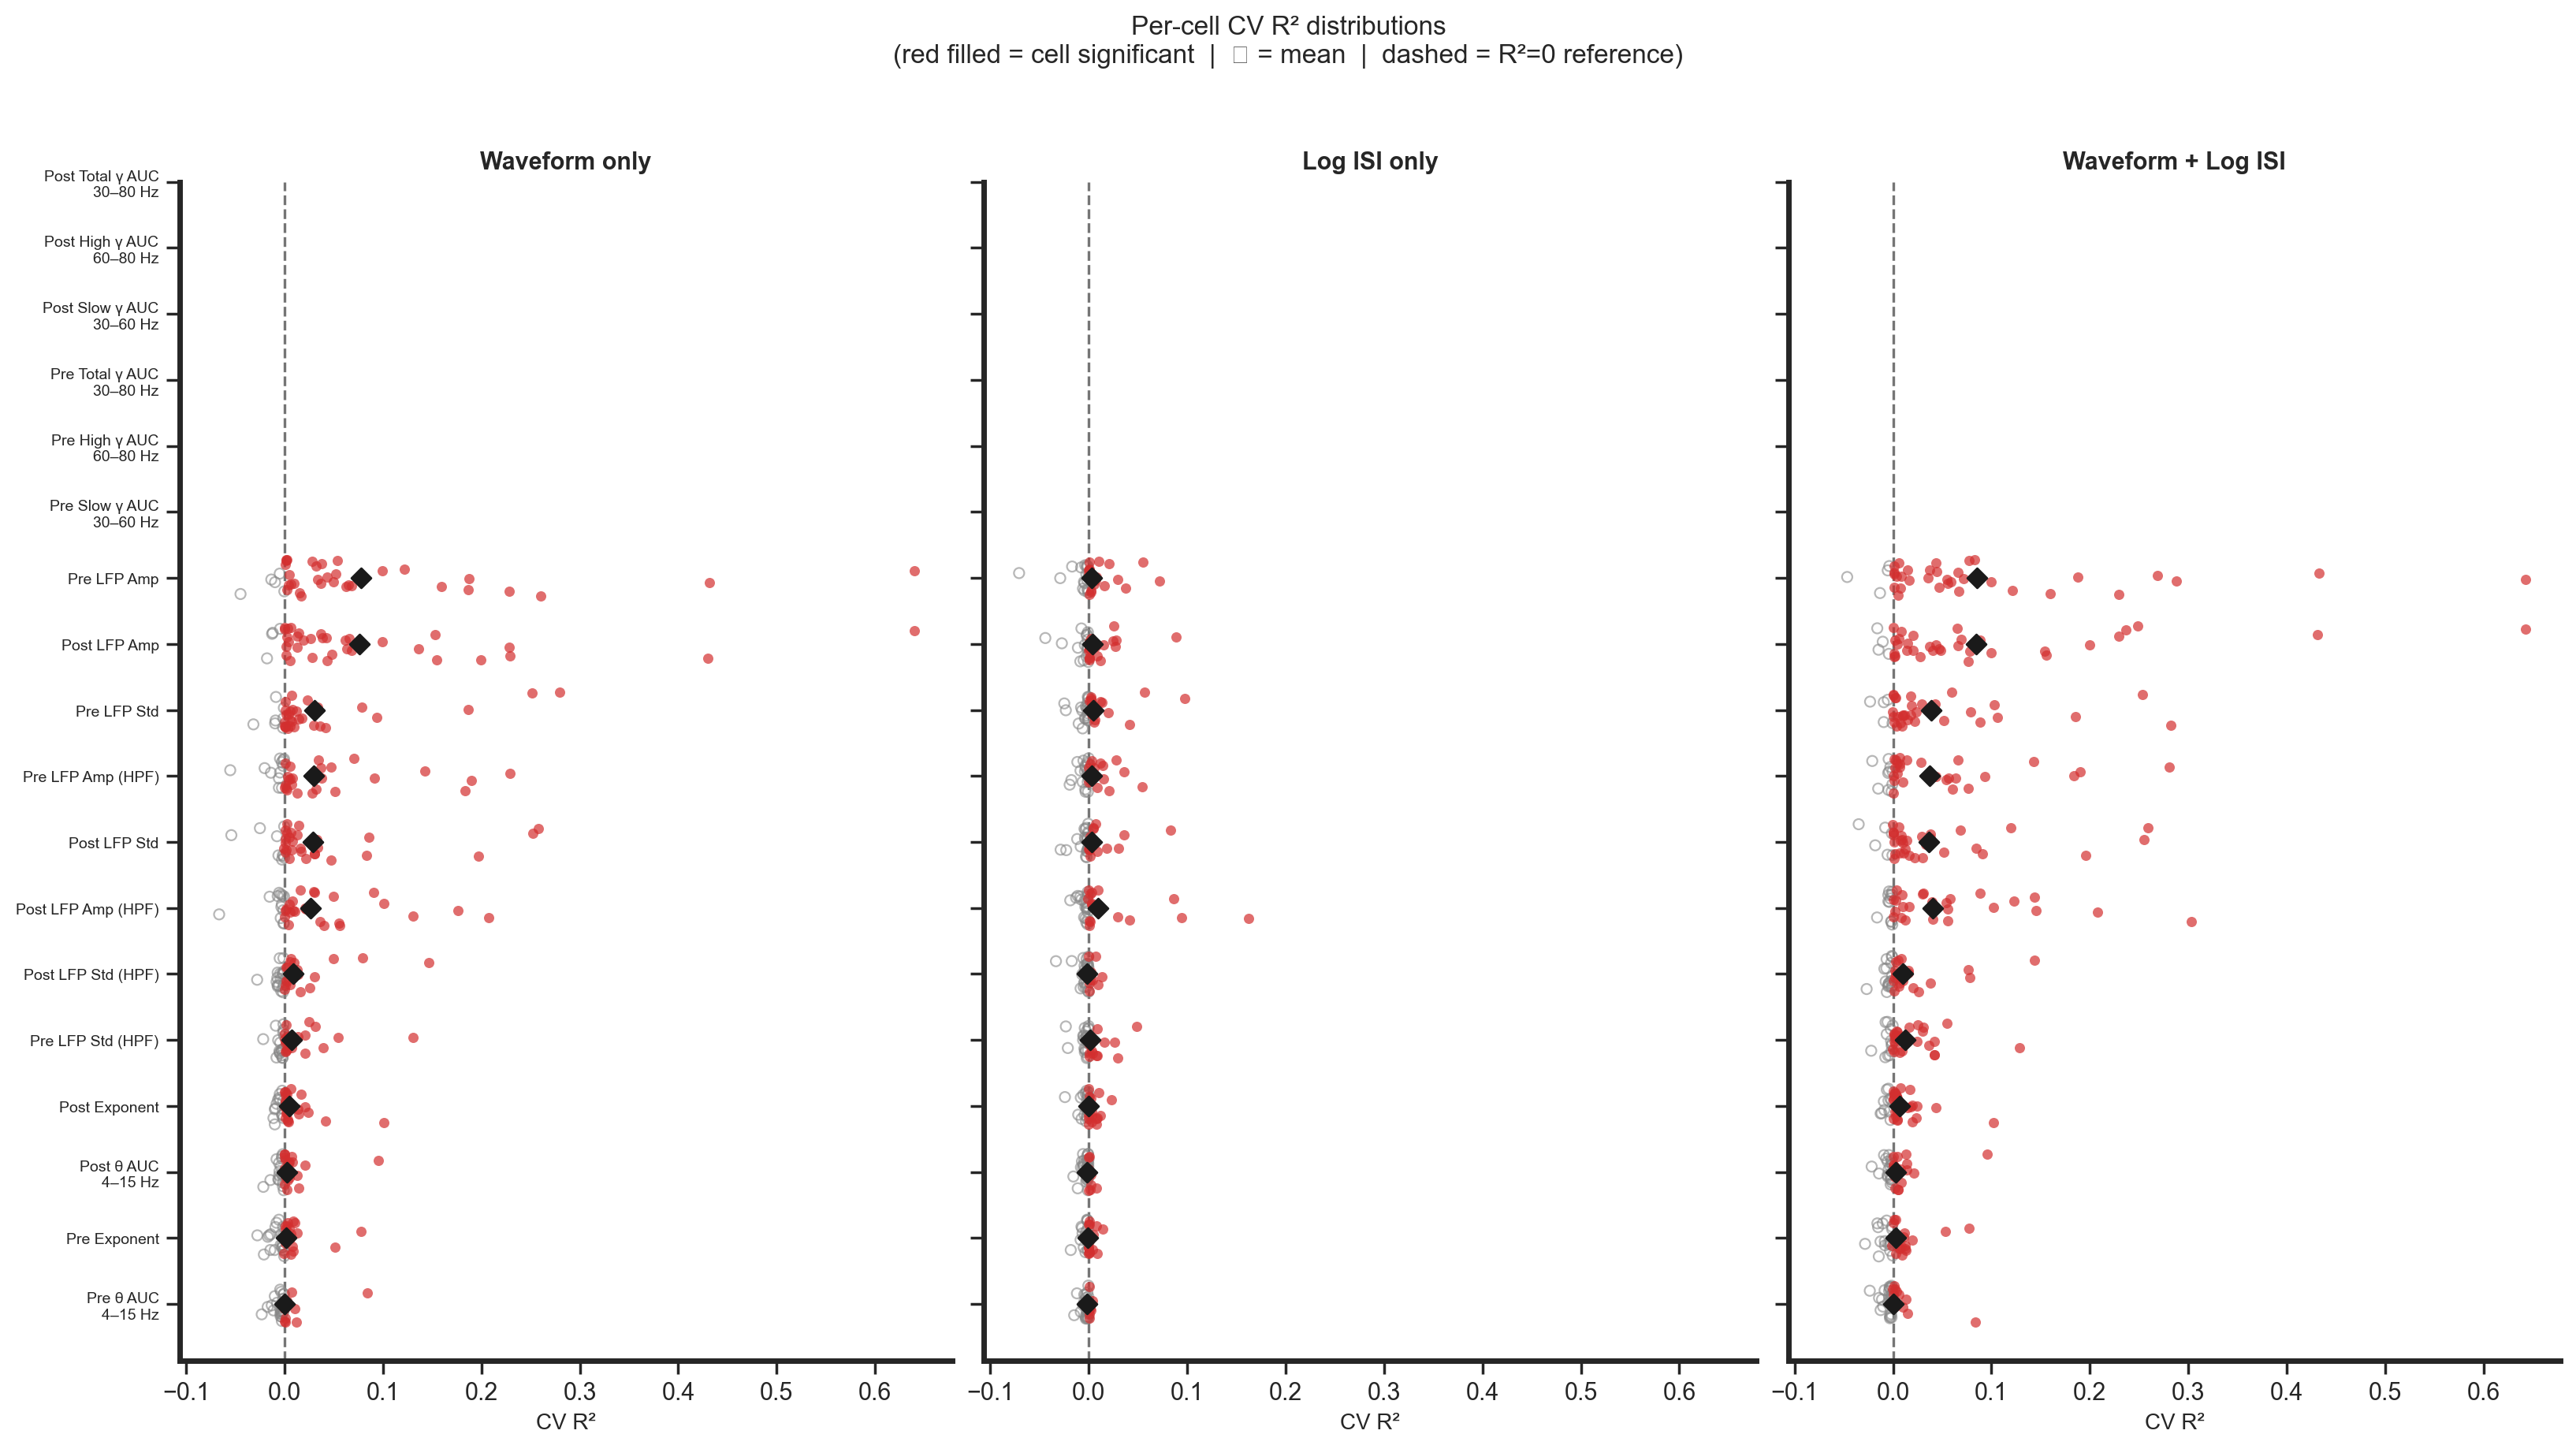

In [17]:
# ── 4b. R² distribution across cells ─────────────────────────────────────────
plot_r2_distributions(
    r2_pop, sig_pop, target_names, target_labels, predictor_sets,
    sort_by='Waveform only', min_r2_line=0.01,
)

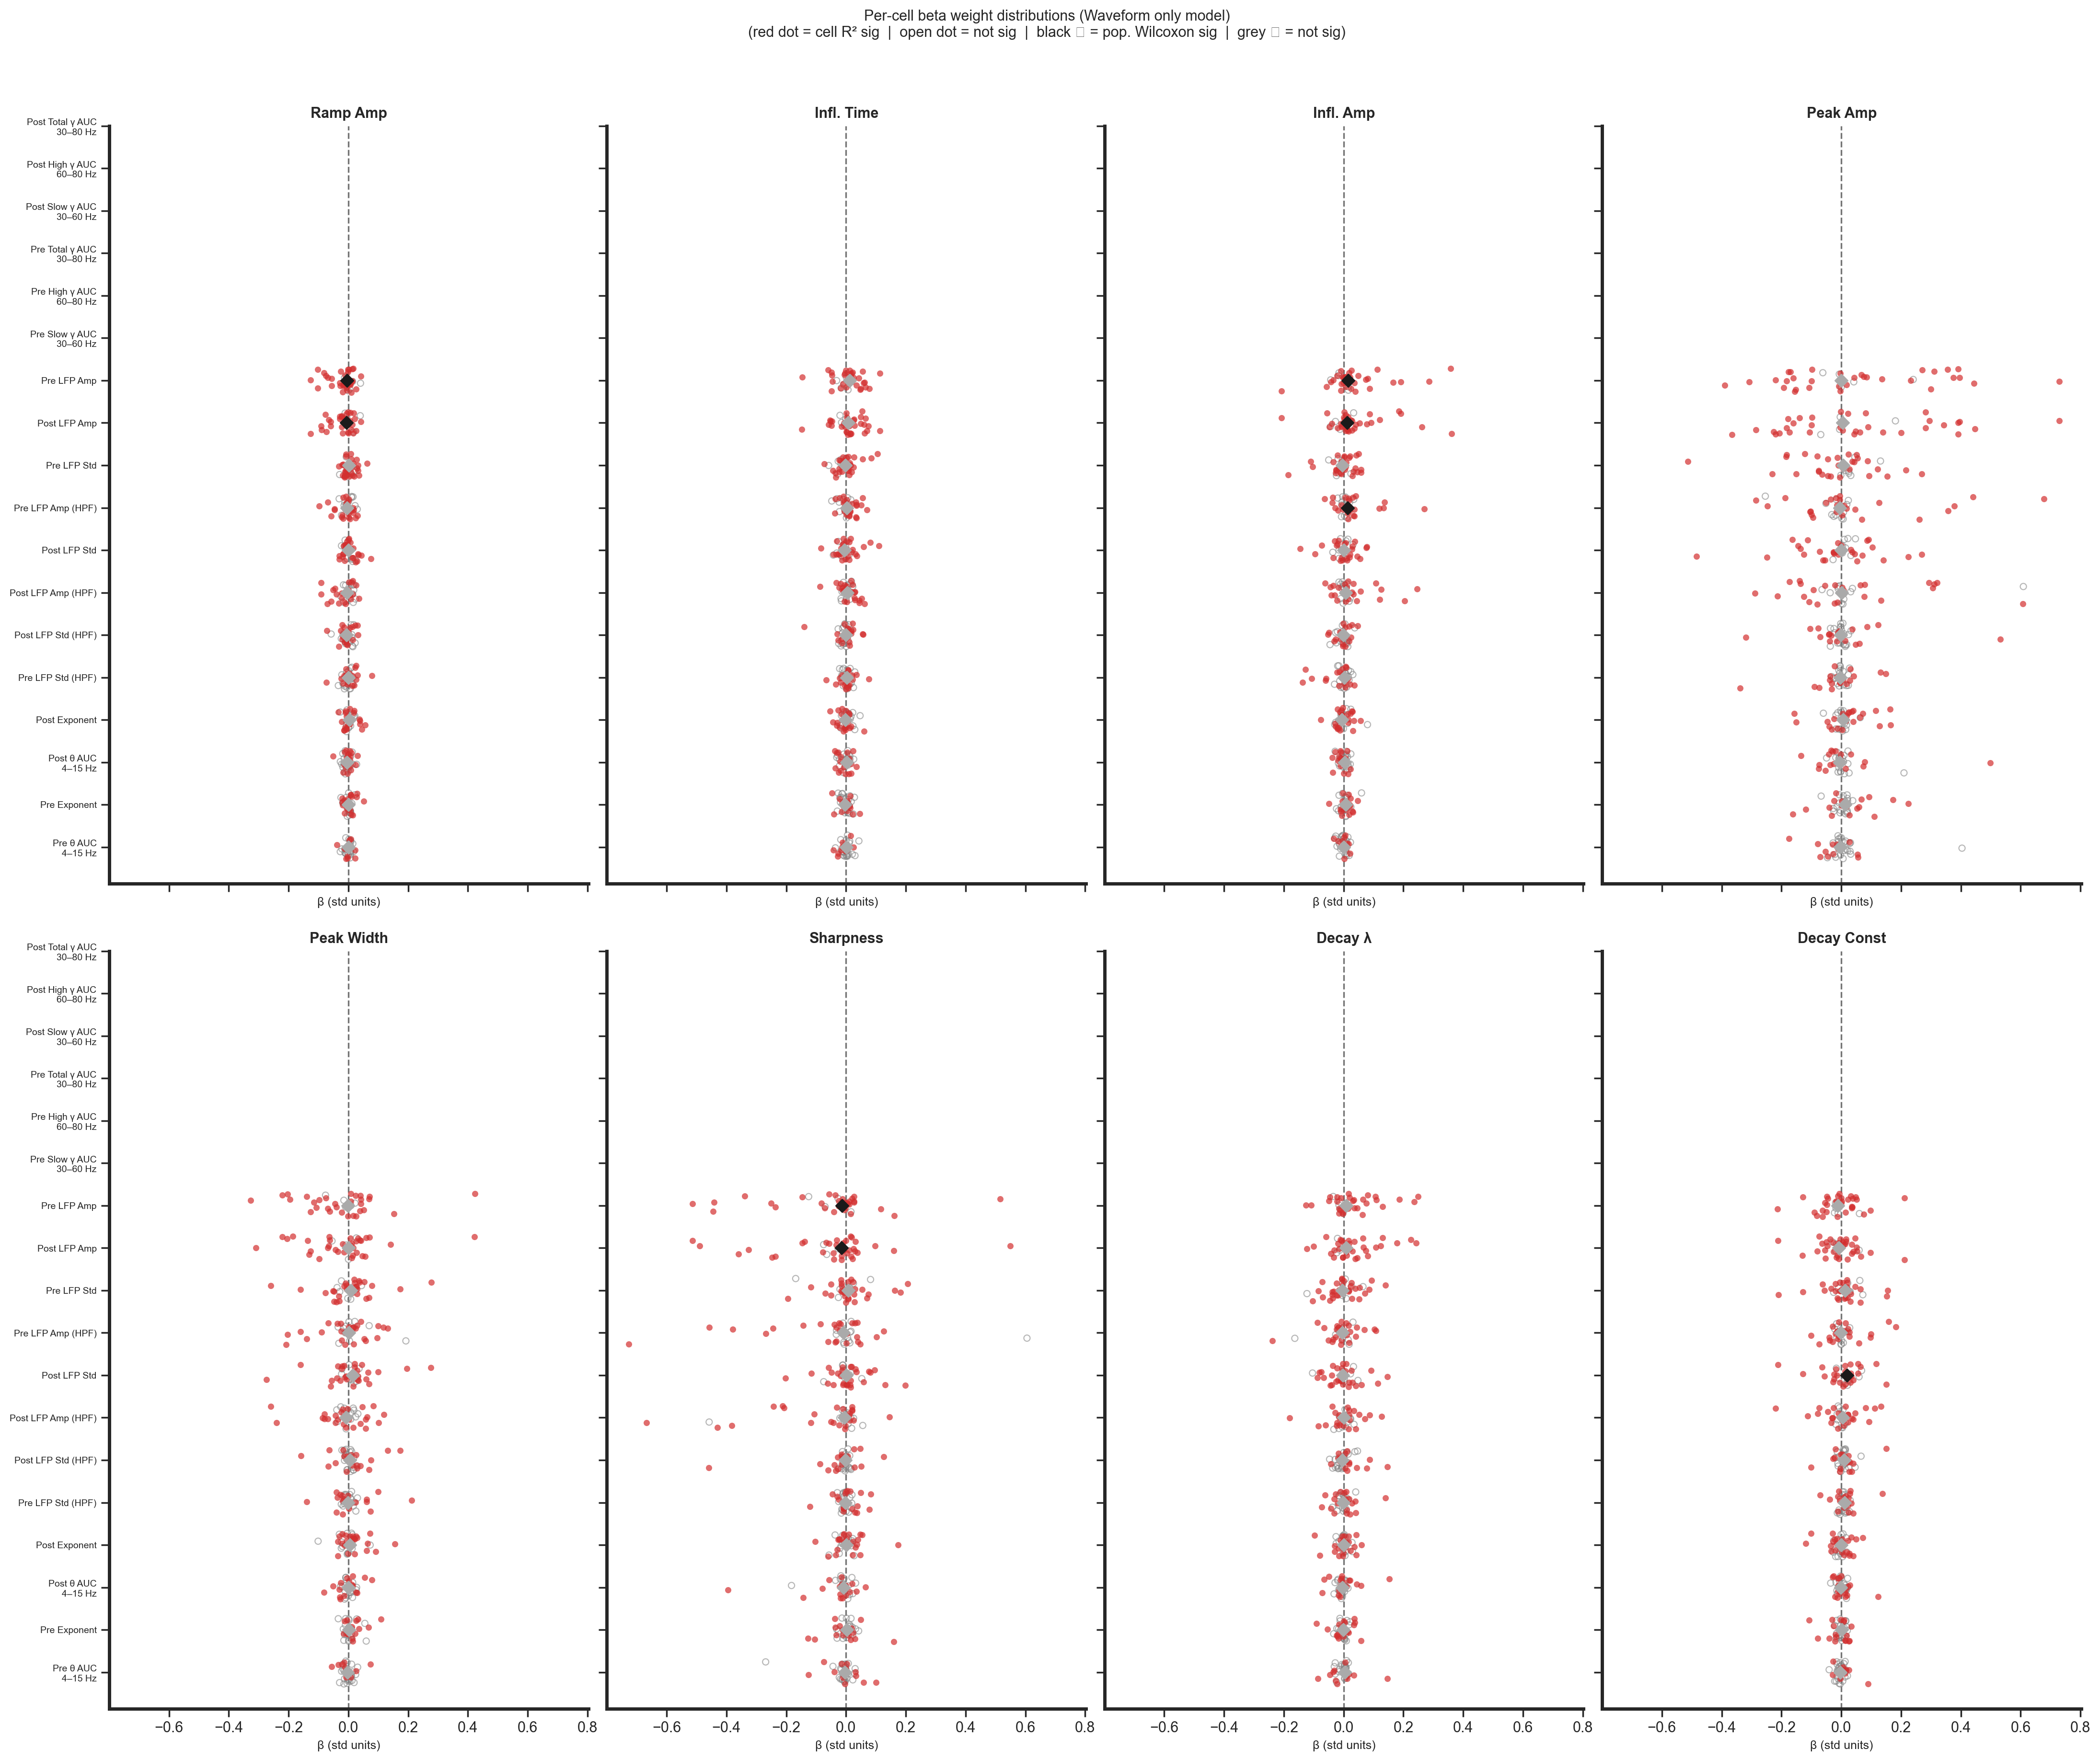

In [18]:
# ── 4c. Beta distributions across cells ──────────────────────────────────────
# One panel per waveform feature; targets sorted by mean R².
# Dot colour: red = that cell's model was significant (raw p < 0.05); grey = not.
# Median ◆: black = population Wilcoxon significant for that (target × feature) pair.
plot_beta_distributions(beta_pop, df_tests, target_names, target_labels,
                        sig_pop=sig_pop, sig_pset='Waveform only',
                        sort_by='mean_r2', r2_pop=r2_pop)

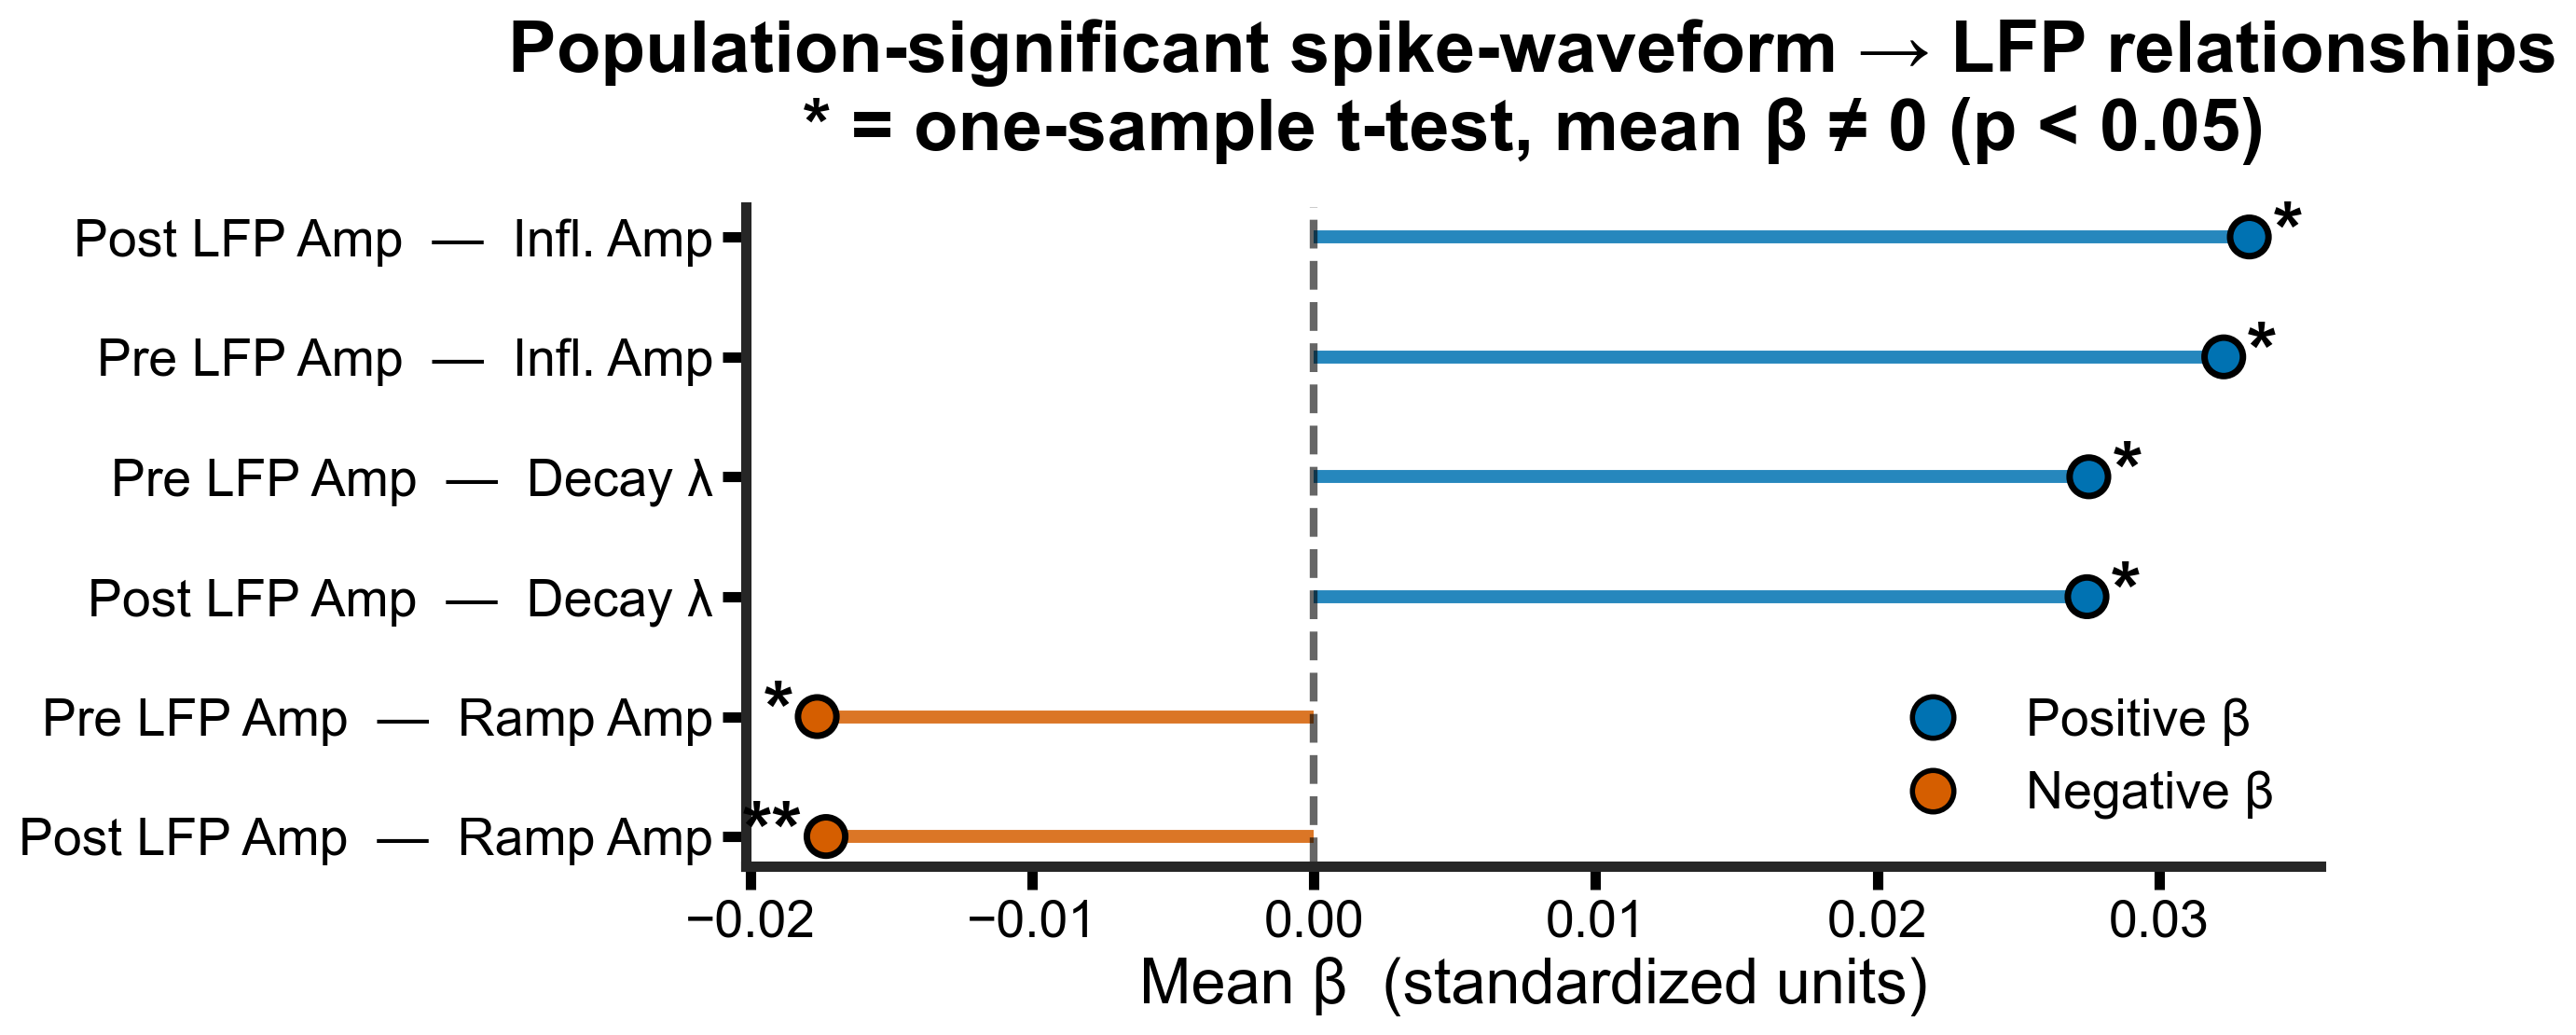

(<Figure size 1300x600 with 1 Axes>,
 <Axes: title={'center': 'Population-significant spike-waveform → LFP relationships\n* = one-sample t-test, mean β ≠ 0 (p < 0.05)'}, xlabel='Mean β  (standardized units)'>)

In [ ]:
# ── 4d. Beta — significant relationships, with directionality (cartoony) ─────
import importlib, pop_ridge_utils
importlib.reload(pop_ridge_utils)
from pop_ridge_utils import plot_beta_significant_summary

plot_beta_significant_summary(df_tests, target_names, target_labels)

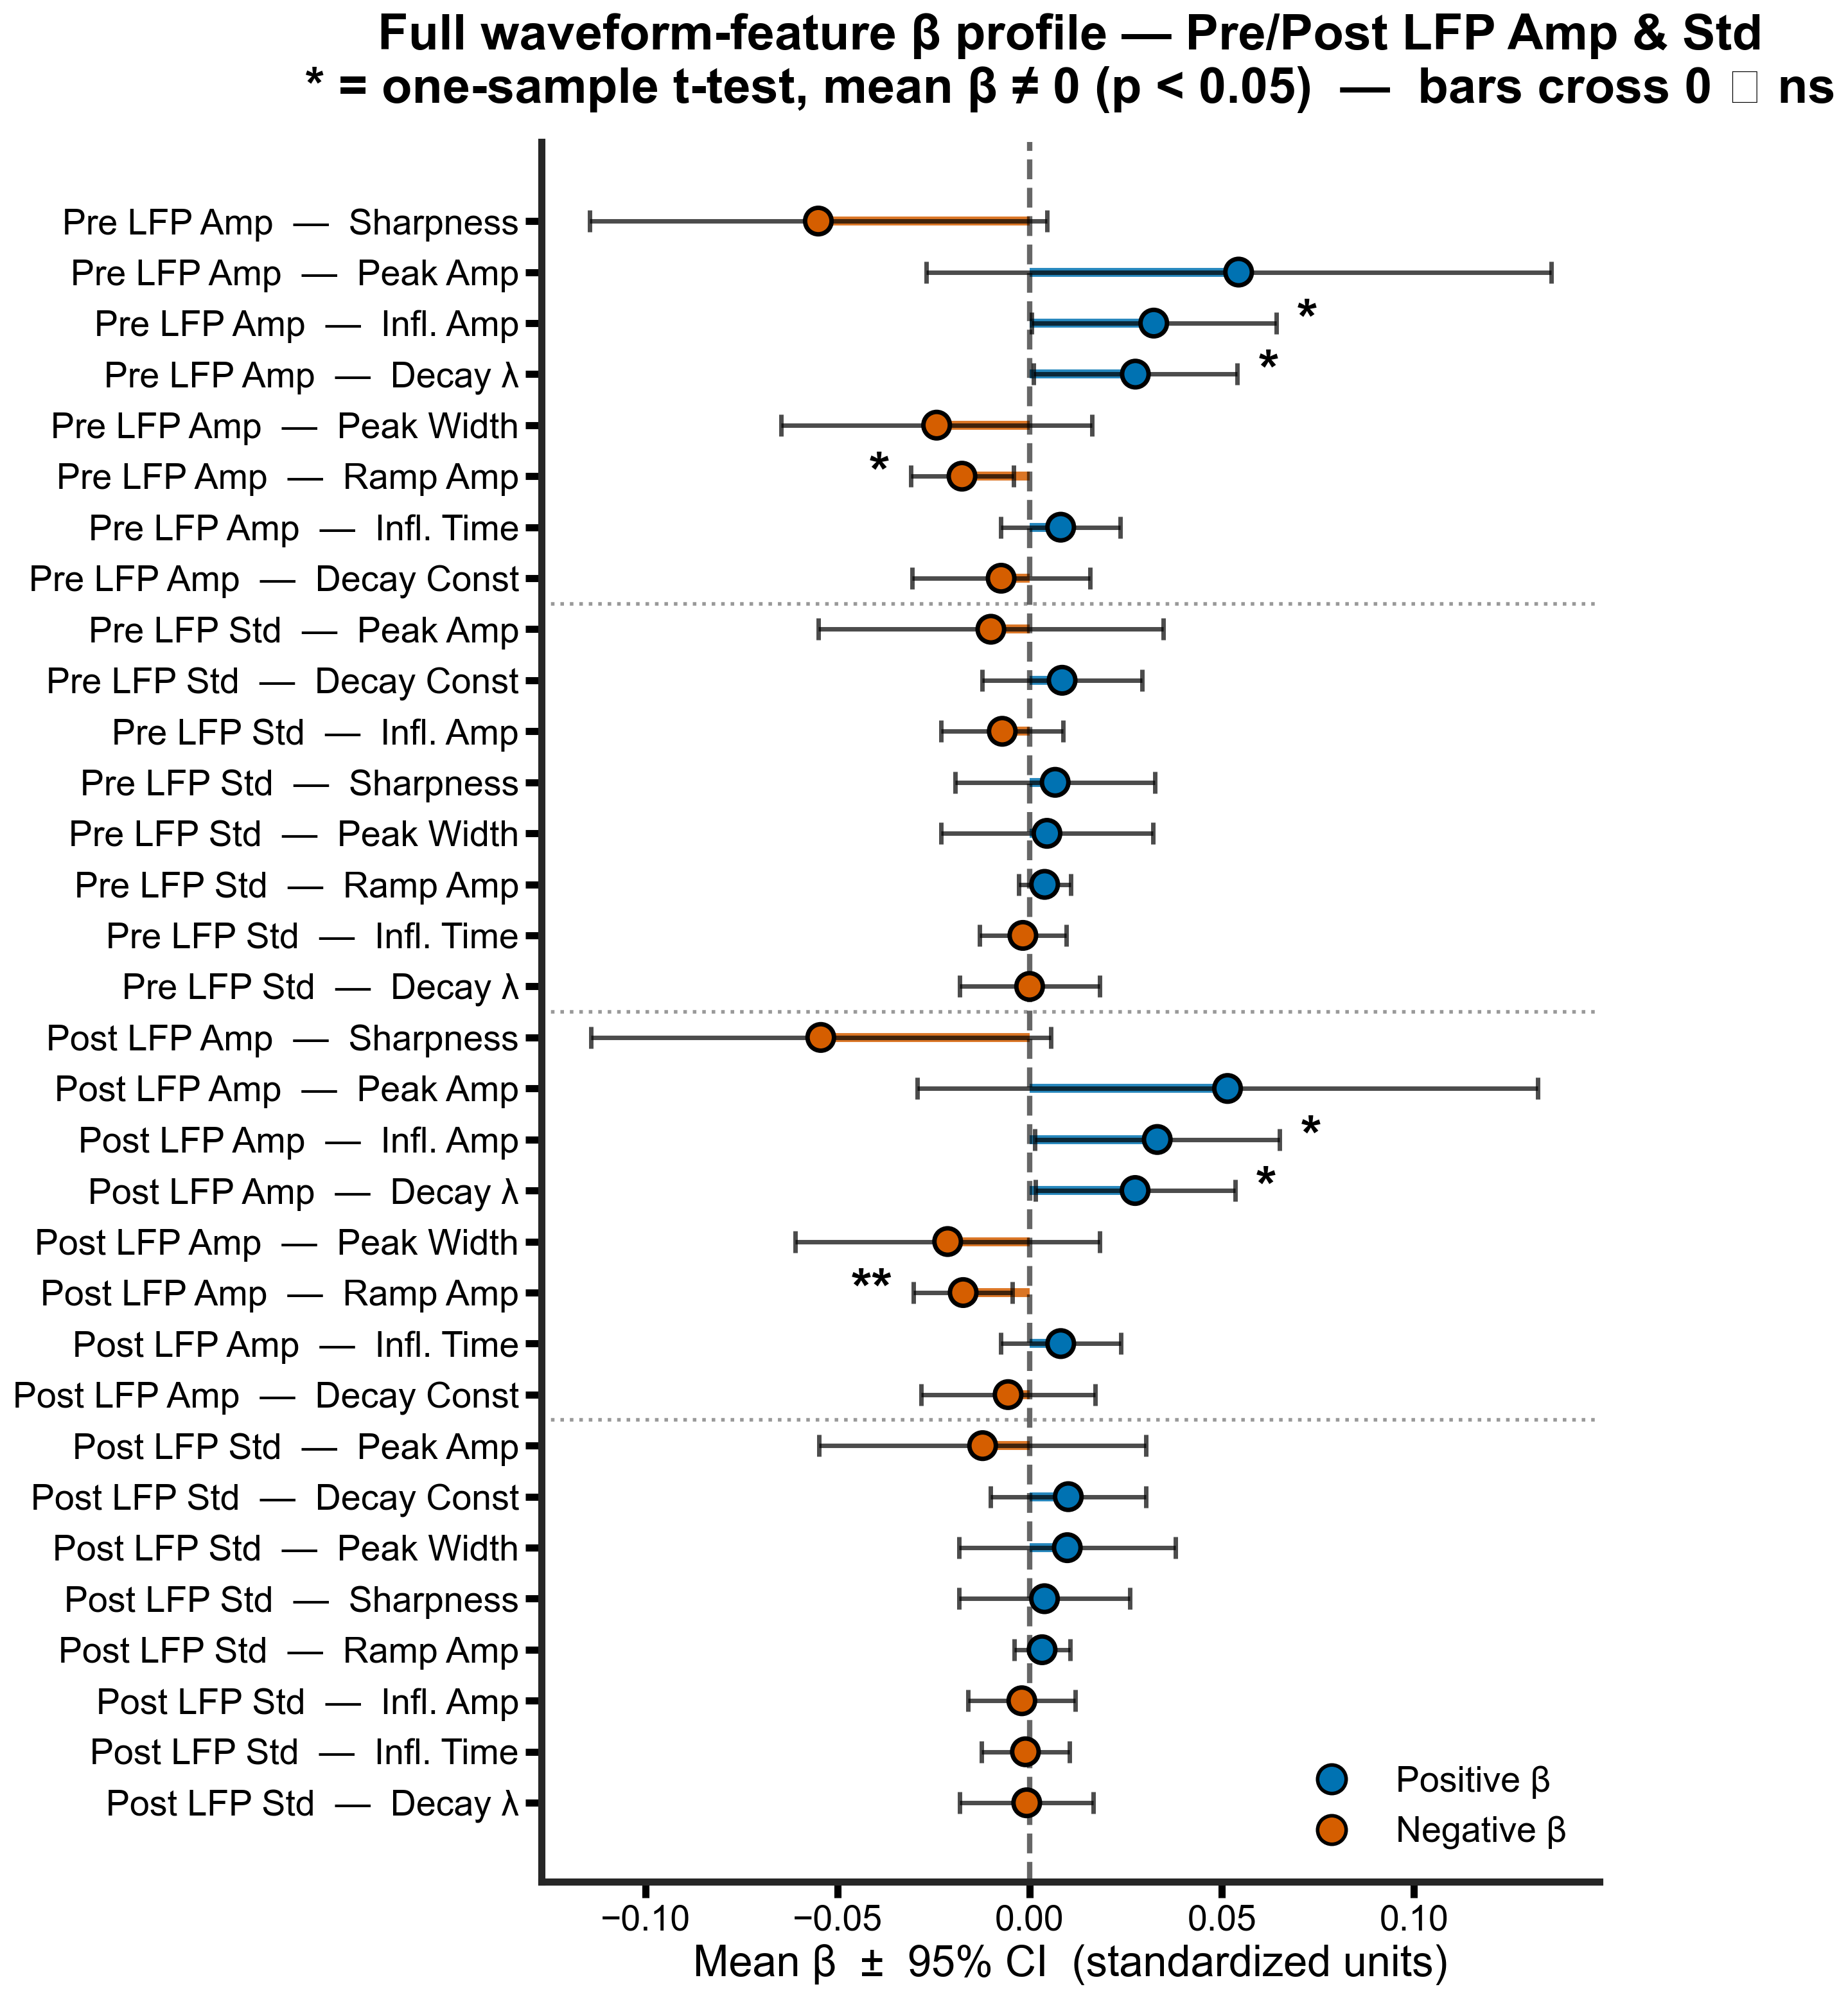

(<Figure size 1300x1600 with 1 Axes>,
 <Axes: title={'center': 'Full waveform-feature β profile — Pre/Post LFP Amp & Std\n* = one-sample t-test, mean β ≠ 0 (p < 0.05)  —  bars cross 0 ⟺ ns'}, xlabel='Mean β  ±  95% CI  (standardized units)'>)

In [ ]:
# ── 4d-ii. Beta — full profile (all 8 features) for Pre/Post LFP Amp & Std ────
from pop_ridge_utils import plot_beta_full_summary

plot_beta_full_summary(df_tests, target_names, target_labels)

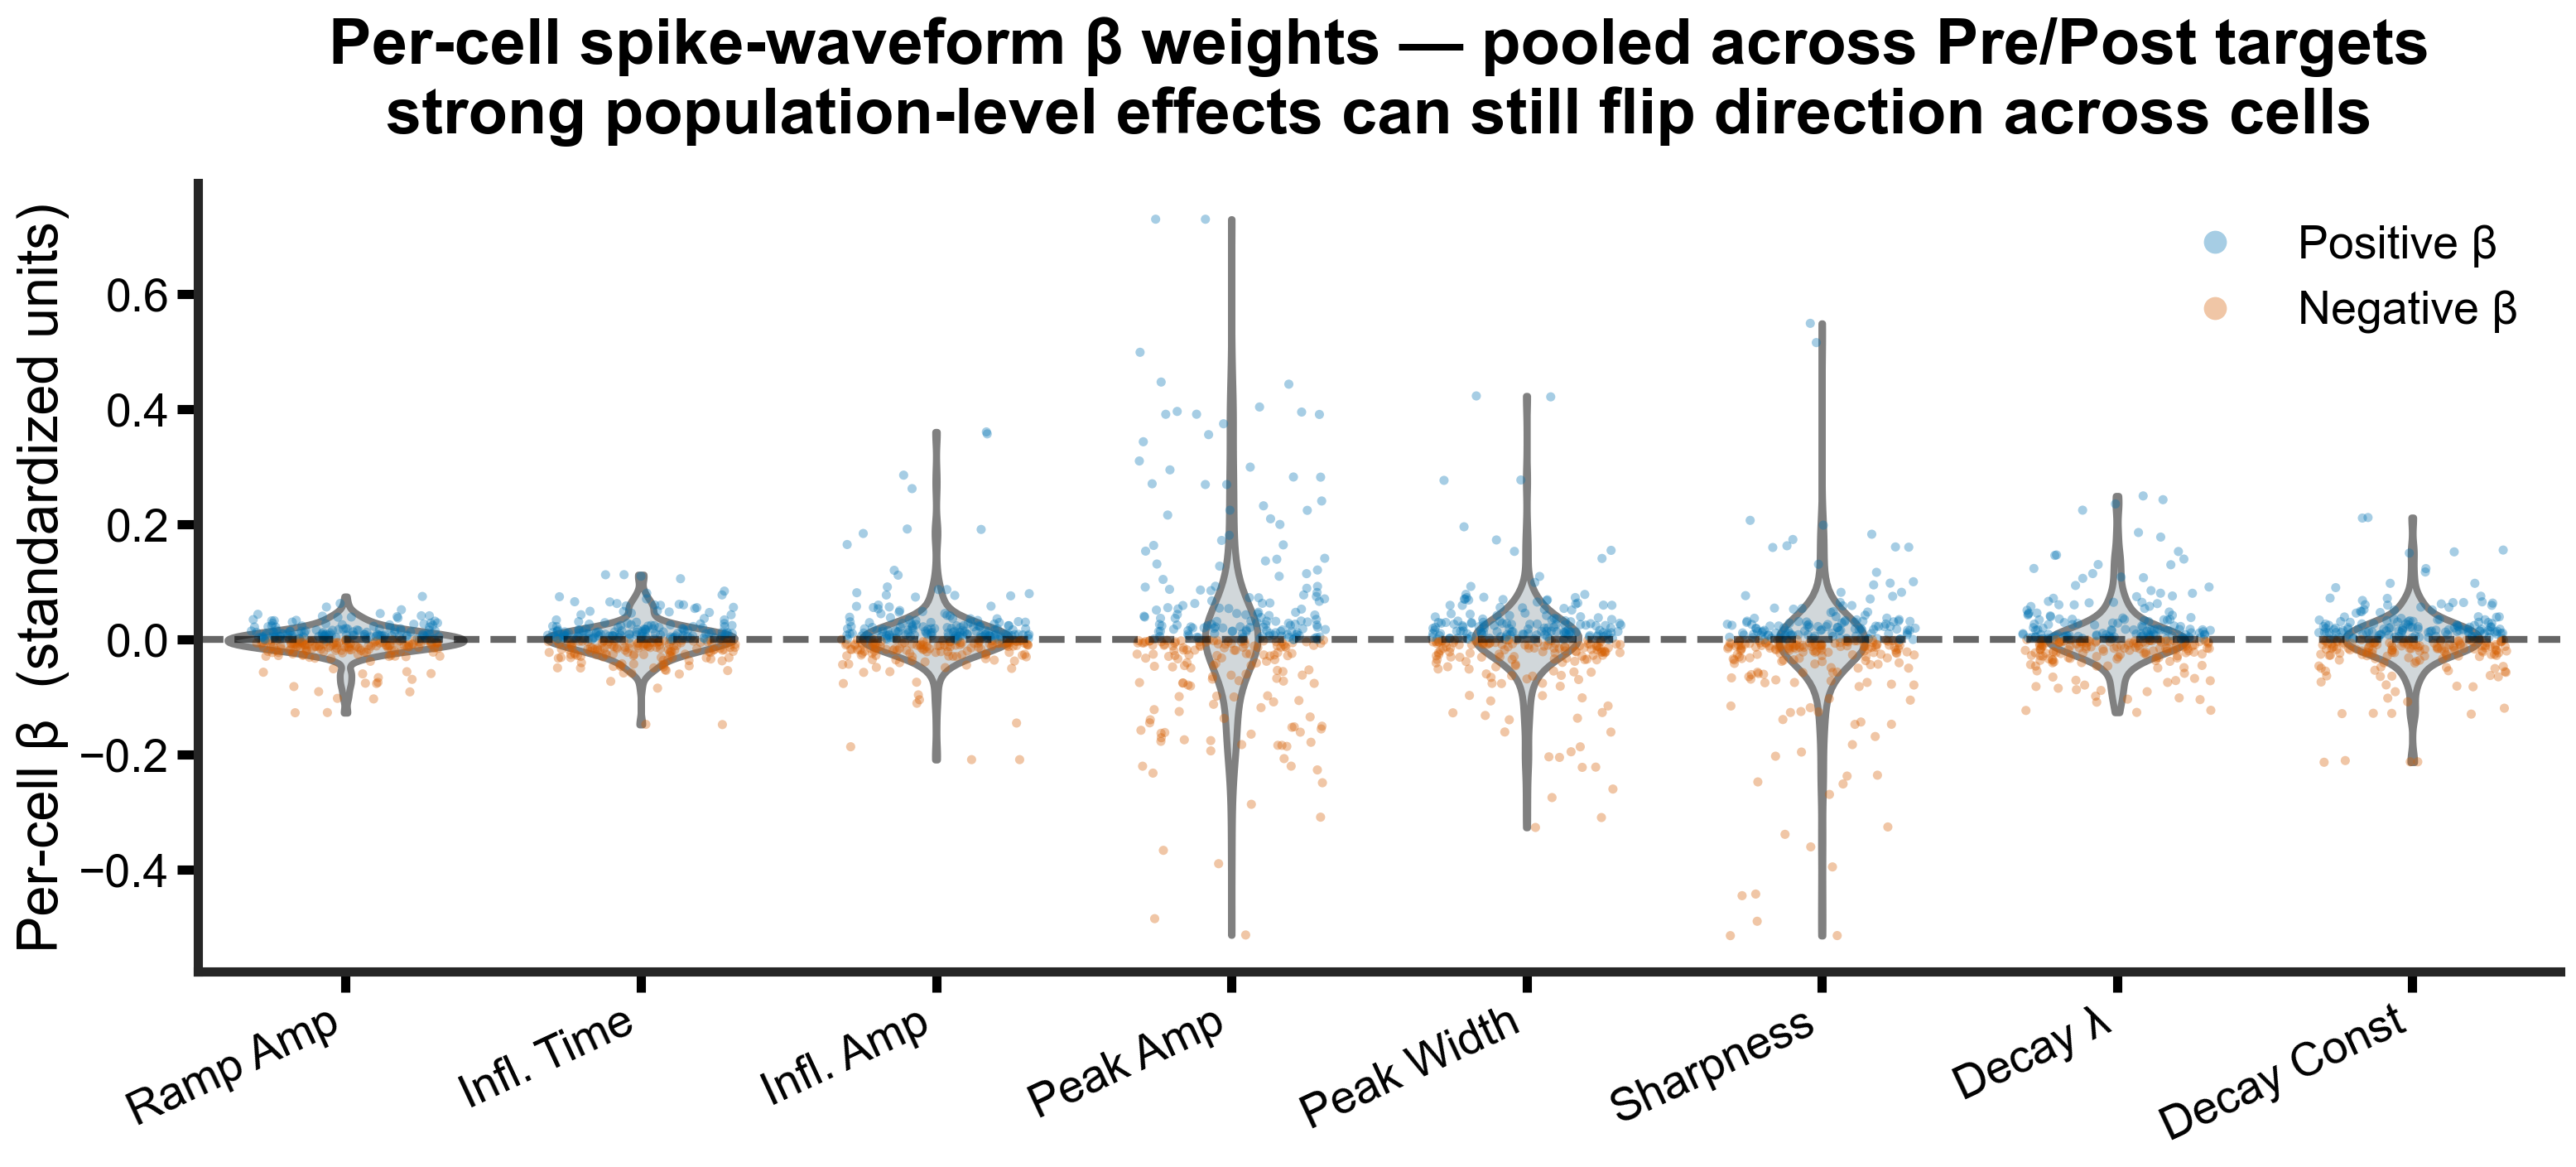

(<Figure size 1600x750 with 1 Axes>,
 <Axes: title={'center': 'Per-cell spike-waveform β weights — pooled across Pre/Post targets\nstrong population-level effects can still flip direction across cells'}, ylabel='Per-cell β  (standardized units)'>)

In [ ]:
# ── 4e. Beta — per-cell heterogeneity across all waveform features (cartoony) ─
from pop_ridge_utils import plot_beta_heterogeneity

plot_beta_heterogeneity(beta_pop, target_names, target_labels)

## 5. Actual vs predicted scatter (pooled)

Each point = one spike from one cell, z-scored within cell before pooling.
Only cells with significant Waveform-only models (raw p < 0.05) included. Each colour = one cell.

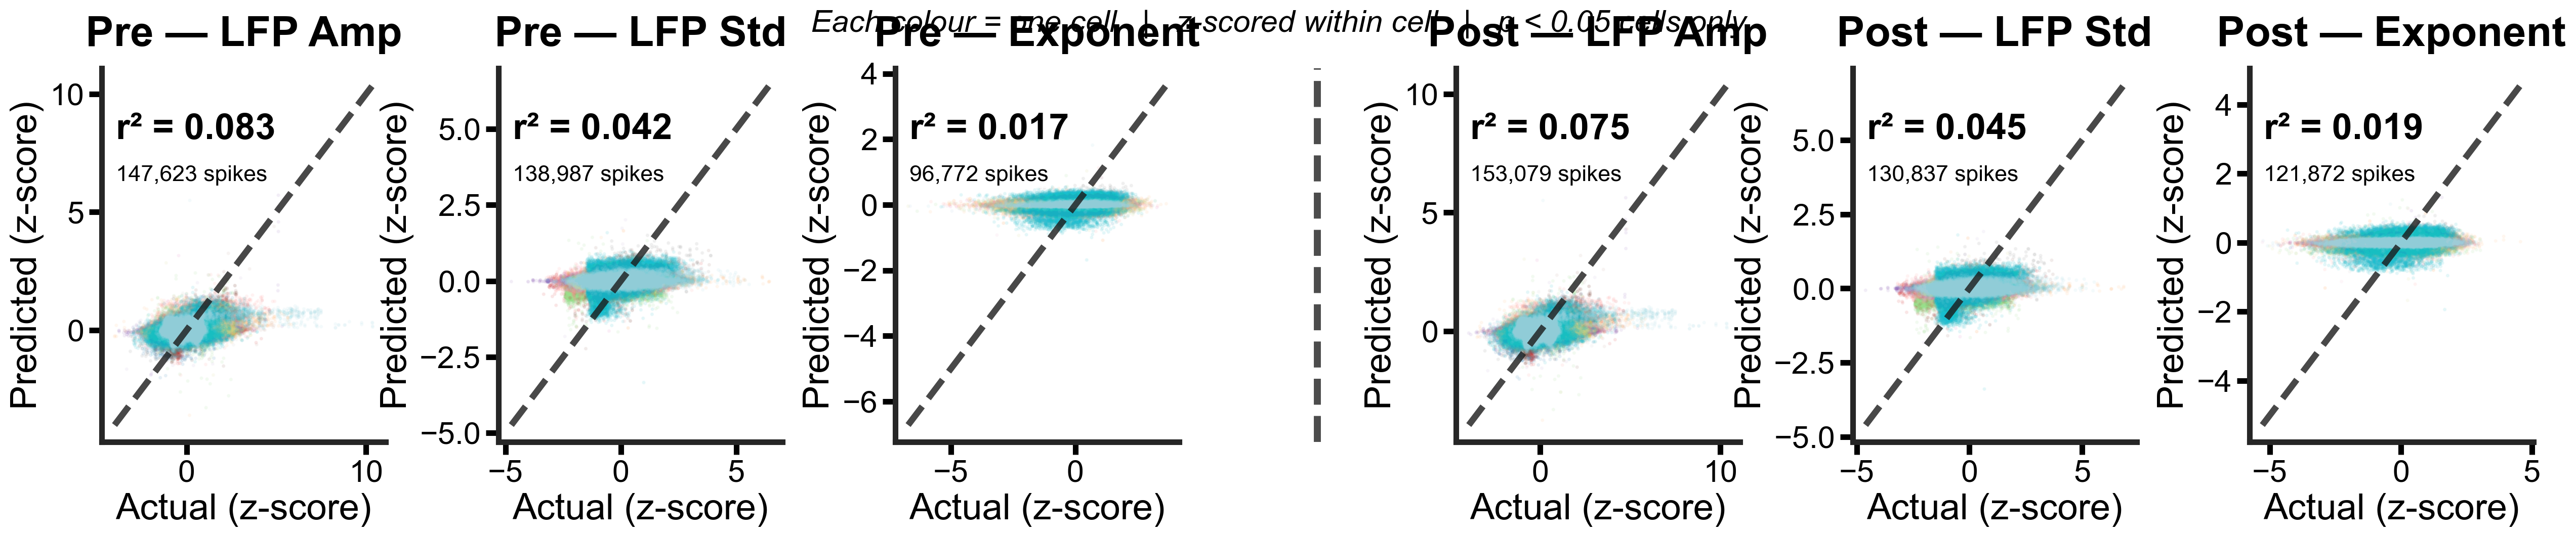

In [ ]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [ ]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
    df_frac=df_frac, df_r2=df_r2,
)

Saved: population_ridge_results.pkl
     target_label     feature  n  median_beta  p_wilcox    p_val
      Pre LFP Amp    Ramp Amp 37    -0.004564  0.040694 0.011332
      Pre LFP Amp   Infl. Amp 37     0.015600  0.034896 0.046946
      Pre LFP Amp   Sharpness 37    -0.013101  0.028630 0.069206
Pre LFP Amp (HPF)   Infl. Amp 37     0.012922  0.018894 0.027985
     Post LFP Amp    Ramp Amp 37    -0.006805  0.022383 0.009823
     Post LFP Amp   Infl. Amp 37     0.011504  0.026403 0.041664
     Post LFP Amp   Sharpness 37    -0.015639  0.029801 0.073665
     Post LFP Std Decay Const 37     0.018625  0.042262 0.320915
